# Phân loại âm thanh hô hấp ICBHI 2017 — Benchmark & Cải tiến

Mục tiêu: xác định các mô hình cơ sở (baseline) đã công bố cho thử thách ICBHI 2017, sau đó cải
tiến mô hình/kiến trúc để vượt qua chúng.

| | |
|---|---|
| **Bài toán** | Phân loại 4 lớp trên từng chu kỳ thở — normal / crackle / wheeze / both |
| **Bộ dữ liệu** | [ICBHI 2017](https://bhichallenge.med.auth.gr/) — 920 bản ghi, 126 bệnh nhân, 6.898 chu kỳ |
| **Độ đo** | ICBHI Score = (Sp + Se) / 2 |
| **Phân chia** | Official 60/40, gần như độc lập theo bệnh nhân *(2/126 ngoại lệ, xem §5)* |
| **Tài nguyên** | Colab Pro (T4/L4) + Kaggle cho các lần chạy dài |

| Bước | Nội dung | Trạng thái |
|---|---|---|
| 1–3 | Độ đo, khảo sát baseline, các hướng cải tiến | ✅ xong *(bên dưới)* |
| 4 | Pipeline dữ liệu + kiểm tra giao thức | 🔲 tiếp theo |
| 5–6 | Chạy ablation, kết quả | 🔲 chưa làm |

Chi tiết đầy đủ cho mọi kết luận trong notebook này (tiếng Anh):
[`docs/01_baselines.md`](docs/01_baselines.md) · [`docs/02_directions.md`](docs/02_directions.md)

---
## 1. Độ đo của ICBHI (không phải accuracy)

$$\mathrm{Sp}=\frac{C_{normal}}{N_{normal}}\qquad
\mathrm{Se}=\frac{C_{crackle}+C_{wheeze}+C_{both}}{N_{crackle}+N_{wheeze}+N_{both}}\qquad
\mathrm{Score}=\frac{\mathrm{Sp}+\mathrm{Se}}{2}$$

Trong đó **Sp** (Specificity) là recall của lớp `normal`, còn **Se** (Sensitivity) là recall gộp
của ba lớp bất thường. Hai chi tiết rất dễ làm sai:

1. **Se gộp ba lớp bất thường thành một tỉ lệ duy nhất** — không phải trung bình cộng (macro) của
   ba recall. Và lớp dự đoán phải trùng **chính xác**: đoán `crackle` cho một chu kỳ `both` được
   tính là **sai**.
2. **Sp và Se có trọng số bằng nhau**, dù dữ liệu có 3.642 chu kỳ `normal` so với chỉ 506 chu kỳ
   `both`. Chính sự mất cân bằng này làm bài toán khó — và đó cũng là khe hở mà phần cải tiến của
   chúng ta sẽ khai thác (§4).

Nói cách khác, ICBHI Score là **balanced accuracy trên hai nhóm** (bình thường / bất thường), chứ
không phải accuracy thông thường, cũng không phải F1.

In [1]:
import numpy as np
import pandas as pd

CLASSES = ("normal", "crackle", "wheeze", "both")


def icbhi_metrics(y_true, y_pred, classes=CLASSES):
    """Độ đo chính thức 4 lớp của ICBHI 2017, trả về đơn vị phần trăm."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    normal = classes[0]
    is_normal = y_true == normal
    if not is_normal.any() or is_normal.all():
        raise ValueError("tập test phải có cả chu kỳ normal lẫn bất thường")

    sp = (y_pred[is_normal] == normal).sum() / is_normal.sum()
    # phải trùng đúng lớp: đoán 'crackle' cho chu kỳ 'both' KHÔNG được tính
    se = (y_pred[~is_normal] == y_true[~is_normal]).sum() / (~is_normal).sum()
    return {"sp": 100 * sp, "se": 100 * se, "score": 100 * (sp + se) / 2}


# Kiểm chứng trên đúng kiểu lỗi cần đề phòng: mô hình luôn đoán 'normal'.
_yt = np.array(["normal"] * 3642 + ["crackle"] * 1864 + ["wheeze"] * 886 + ["both"] * 506)
_yp = np.full_like(_yt, "normal")
_m = icbhi_metrics(_yt, _yp)
print(f"luôn đoán normal:  Sp={_m['sp']:.2f}  Se={_m['se']:.2f}  Score={_m['score']:.2f}")
print(f"accuracy thường:   {100 * (_yt == _yp).mean():.2f}   <- nghe được nhưng vô dụng")

luôn đoán normal:  Sp=100.00  Se=0.00  Score=50.00
accuracy thường:   52.80   <- nghe được nhưng vô dụng


Mô hình trên đoán `normal` cho **mọi** mẫu — hoàn toàn vô dụng về mặt lâm sàng vì không phát hiện
được ca bệnh nào. Nhưng vì lớp `normal` chiếm 52,8 % dữ liệu, **accuracy vẫn cho ra 52,80 %**,
che giấu hoàn toàn thất bại đó.

ICBHI Score thì không bị đánh lừa: `Se = 0` phơi bày ngay vấn đề. Đây là lý do phải cảnh giác khi
một bài báo chỉ báo cáo accuracy trên ICBHI.

---
## 2. ⚠ Cái bẫy khi so sánh kết quả

Kết quả ICBHI đã công bố trải dài từ ~50 % đến ~99 %, và **phần lớn khoảng chênh lệch đó đến từ
giao thức đánh giá, không phải từ chất lượng mô hình.** Có ba giao thức không tương thích nhau
đang cùng lưu hành:

| Giao thức | Score báo cáo | So sánh được? |
|---|---|---|
| **Official 60/40** (`ICBHI_challenge_train_test.txt`, gần như tách theo bệnh nhân) | 50–66 % | ✅ đây là benchmark |
| Random 80/20, vẫn tách theo bệnh nhân | 65–75 % | ⚠ một dòng nghiên cứu khác |
| Chia ngẫu nhiên ở mức **chu kỳ** (cùng bệnh nhân ở cả train **và** test) | 90–99 % | ❌ rò rỉ bệnh nhân |

Bài nào công bố ">95 % trên ICBHI" thì gần như chắc chắn đang chia ở mức chu kỳ — mô hình học
thuộc bệnh nhân chứ không học bệnh lý. Mọi con số bên dưới đều dùng official split, và §5 **kiểm
tra bằng code** thay vì tin tưởng.

---
## 3. Khảo sát baseline (2020–2026)

Tổng hợp từ bốn bài báo dùng chung một giao thức và cùng tái lập lại các dòng kết quả của nhau —
[BTS](https://arxiv.org/abs/2406.06786), [Ensemble-KD](https://arxiv.org/abs/2505.22027),
[QLung](https://arxiv.org/abs/2606.11915), [PAFA](https://arxiv.org/abs/2505.23834) — nên các
dòng dưới đây nhất quán với nhau, không phải gom góp từ những abstract rời rạc.

In [2]:
# ICBHI 4 lớp, official 60/40 tách theo bệnh nhân. NaN = bài báo không báo cáo.
_B = [
    # phương pháp, năm, backbone, thế hệ backbone (chỉ dùng để tô màu biểu đồ), Sp, Se, Score, repo code
    ("SE+SA",                  2020, "ResNet18",     "CNN",    81.25, 17.84, 49.55, ""),
    ("Ren et al.",             2022, "CNN8-Pt",      "CNN",    72.96, 27.78, 50.37, ""),
    ("LungRN+NL",              2020, "ResNet-NL",    "CNN",    63.20, 41.32, 52.26, ""),
    ("Chang et al.",           2022, "CNN8-dilated", "CNN",    69.92, 35.85, 52.89, ""),
    ("Moummad (CE)",           2023, "CNN6",         "CNN",    70.09, 40.39, 55.24, "ilyassmoummad/scl_icbhi2017"),
    ("Wang (Splice)",          2022, "ResNeSt",      "CNN",    70.40, 40.20, 55.30, ""),
    ("RespireNet",             2021, "ResNet34",     "CNN",    72.30, 40.10, 56.20, "microsoft/RespireNet"),
    ("Late-Fusion",            2022, "Inc-03+VGG14", "CNN",    85.60, 30.00, 57.30, ""),
    ("Moummad (SCL)",          2023, "CNN6",         "CNN",    75.95, 39.15, 57.55, "ilyassmoummad/scl_icbhi2017"),
    ("Nguyen (StochNorm)",     2022, "ResNet50",     "CNN",    78.86, 36.40, 57.63, ""),
    ("Nguyen (Co-Tuning)",     2022, "ResNet50",     "CNN",    79.34, 37.24, 58.29, ""),
    ("AST + CE",               2023, "AST",          "AST",    77.14, 41.97, 59.55, "raymin0223/patch-mix_contrastive_learning"),
    ("RepAugment",             2024, "AST",          "AST",    82.47, 40.55, 61.51, "RSC-Toolkit/RepAugment"),
    ("SG-SCL",                 2024, "AST",          "AST",    79.87, 43.55, 61.71, "kaen2891/stethoscope-guided_supervised_contrastive_learning"),
    ("AFT (Mixed-500)",        2023, "AST",          "AST",    80.72, 42.86, 61.79, "kaen2891/adversarial_fine-tuning_using_generated_respiratory_sound"),
    ("AST + Patch-Mix CL",     2023, "AST",          "AST",    81.66, 43.07, 62.37, "raymin0223/patch-mix_contrastive_learning"),
    ("Audio-CLAP",             2024, "CLAP",         "Modern", 80.85, 44.67, 62.56, "kaen2891/bts"),
    ("QLung",                  2026, "CLAP",         "Modern", 81.98, 44.81, 63.39, "RSC-Toolkit/QLung"),
    ("BEATs + CE",             2025, "BEATs",        "Modern", 78.77, 48.21, 63.49, "wa976/PAFA"),
    ("BTS",                    2024, "CLAP",         "Modern", 81.40, 45.67, 63.54, "kaen2891/bts"),
    ("BTS-d (KD, k=15)",       2025, "CLAP",         "Modern", 82.89, 45.90, 64.39, "RSC-Toolkit/rsc-ensemble-kd"),
    ("Lung-SRAD",              2026, "DASS (SSM)",   "Modern", 79.53, 49.42, 64.48, "RSC-Toolkit/Lung-SRAD"),
    ("PAFA",                   2025, "BEATs",        "Modern", 82.05, 47.63, 64.84, "wa976/PAFA"),
    ("BTS-d++ (2nd-gen ens.)", 2025, "CLAP",         "Modern", 88.09, 42.82, 65.45, "RSC-Toolkit/rsc-ensemble-kd"),
    ("ADD-RSC",                2025, "n/r",          "Modern", np.nan, np.nan, 65.53, "deegy666/ADD-RSC"),
    ("BTS++ (k=30, 30x cost)", 2025, "CLAP",         "Modern", np.nan, np.nan, 65.69, "RSC-Toolkit/rsc-ensemble-kd"),
    ("Meta-Ensemble",          2026, "n/r",          "Modern", np.nan, np.nan, 66.49, ""),
]

baselines = pd.DataFrame(_B, columns=["method", "year", "backbone", "era", "sp", "se", "score", "code"])
baselines = baselines.sort_values("score", ignore_index=True)

print(f"{len(baselines)} baseline | Score {baselines.score.min():.2f} - {baselines.score.max():.2f}")
baselines[["method", "year", "backbone", "sp", "se", "score", "code"]].style.hide(axis="index").format(
    {"sp": "{:.2f}", "se": "{:.2f}", "score": "{:.2f}"}, na_rep="—"
).background_gradient(subset=["score"], cmap="Blues")

27 baseline | Score 49.55 - 66.49


method,year,backbone,sp,se,score,code
SE+SA,2020,ResNet18,81.25,17.84,49.55,
Ren et al.,2022,CNN8-Pt,72.96,27.78,50.37,
LungRN+NL,2020,ResNet-NL,63.20,41.32,52.26,
Chang et al.,2022,CNN8-dilated,69.92,35.85,52.89,
Moummad (CE),2023,CNN6,70.09,40.39,55.24,ilyassmoummad/scl_icbhi2017
Wang (Splice),2022,ResNeSt,70.40,40.20,55.30,
RespireNet,2021,ResNet34,72.30,40.10,56.20,microsoft/RespireNet
Late-Fusion,2022,Inc-03+VGG14,85.60,30.00,57.30,
Moummad (SCL),2023,CNN6,75.95,39.15,57.55,ilyassmoummad/scl_icbhi2017
Nguyen (StochNorm),2022,ResNet50,78.86,36.40,57.63,


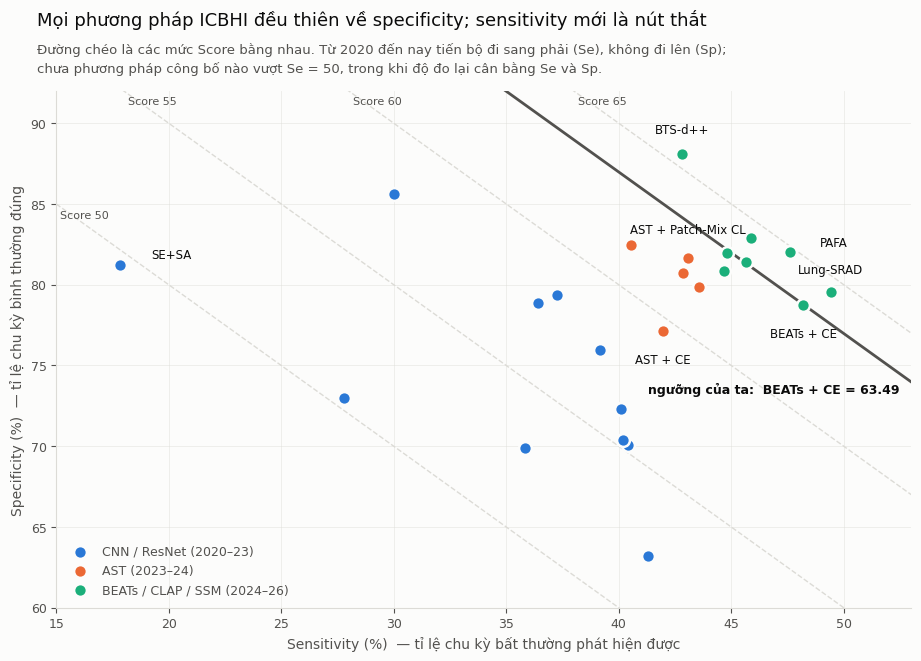

In [3]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdbd6"
ERA_COLOR = {"CNN": "#2a78d6", "AST": "#eb6834", "Modern": "#1baf7a"}
ERA_LABEL = {"CNN": "CNN / ResNet (2020–23)", "AST": "AST (2023–24)",
             "Modern": "BEATs / CLAP / SSM (2024–26)"}
OUR_BAR = 63.49  # BEATs + CE - ngưỡng mà phần cải tiến của chúng ta phải vượt

pts = baselines.dropna(subset=["sp", "se"])
fig, ax = plt.subplots(figsize=(9.5, 6.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
XLIM, YLIM = (15, 53), (60, 92)

# các đường đẳng Score: Sp = 2*Score - Se
for s in (50, 55, 60, 65):
    ax.plot(XLIM, [2 * s - XLIM[0], 2 * s - XLIM[1]], ls="--", lw=1, color=GRID, zorder=1)
    ax.annotate(f"Score {s}", (max(XLIM[0], 2 * s - YLIM[1]), min(YLIM[1], 2 * s - XLIM[0])),
                xytext=(3, -10), textcoords="offset points", fontsize=8, color=INK2, zorder=1)

# đường quan trọng nhất: ngưỡng mà mô hình cải tiến phải vượt qua
ax.plot(XLIM, [2 * OUR_BAR - XLIM[0], 2 * OUR_BAR - XLIM[1]], lw=2, color=INK2, zorder=2)
ax.annotate(f"ngưỡng của ta:  BEATs + CE = {OUR_BAR}", (52.5, 2 * OUR_BAR - 52.5),
            xytext=(0, -6), textcoords="offset points", ha="right", va="top",
            fontsize=9, color=INK, fontweight="bold", zorder=2)

for era, g in pts.groupby("era", sort=False):
    ax.scatter(g.se, g.sp, s=85, color=ERA_COLOR[era], label=ERA_LABEL[era],
               edgecolor=SURFACE, linewidth=1.8, zorder=3)

LABELS = {  # dx, dy, ha — đặt tay để nhãn không đè lên điểm nào
    "SE+SA": (1.4, 0.4, "left"), "AST + CE": (0, -2.0, "center"),
    "AST + Patch-Mix CL": (0, 1.5, "center"), "BTS-d++ (2nd-gen ens.)": (0, 1.3, "center"),
    "PAFA": (1.3, 0.3, "left"), "BEATs + CE": (0, -2.0, "center"),
    "Lung-SRAD": (0, 1.15, "center"),
}
for _, r in pts.iterrows():
    if r.method in LABELS:
        dx, dy, ha = LABELS[r.method]
        name = "BTS-d++" if r.method.startswith("BTS-d++") else r.method
        ax.annotate(name, (r.se + dx, r.sp + dy), ha=ha, fontsize=8.5, color=INK, zorder=4)

ax.set(xlim=XLIM, ylim=YLIM,
       xlabel="Sensitivity (%)  — tỉ lệ chu kỳ bất thường phát hiện được",
       ylabel="Specificity (%)  — tỉ lệ chu kỳ bình thường đúng")
fig.text(0.055, 0.965, "Mọi phương pháp ICBHI đều thiên về specificity; sensitivity mới là nút thắt",
         fontsize=13, color=INK, va="top")
fig.text(0.055, 0.917,
         "Đường chéo là các mức Score bằng nhau. Từ 2020 đến nay tiến bộ đi sang phải (Se), không đi lên (Sp);\n"
         "chưa phương pháp công bố nào vượt Se = 50, trong khi độ đo lại cân bằng Se và Sp.",
         fontsize=9.5, color=INK2, va="top", linespacing=1.5)
ax.grid(True, color=GRID, lw=0.6, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.tick_params(colors=INK2, labelsize=9)
ax.xaxis.label.set_color(INK2)
ax.yaxis.label.set_color(INK2)
ax.legend(loc="lower left", frameon=False, fontsize=9, labelcolor=INK2)
fig.subplots_adjust(left=0.075, right=0.975, top=0.845, bottom=0.085)
plt.show()

---
## 4. Bảng kết quả cho ta biết điều gì

**1 · Sensitivity mới là nút thắt.** Mọi phương pháp đều đạt Sp 63–88 nhưng Se chỉ 18–49.
**Chưa từng có phương pháp công bố nào vượt Se = 50**, trong khi Score lại cân bằng Se và Sp. Toàn
bộ dư địa của benchmark nằm trên trục Se — và đúng là những phương pháp mạnh gần đây (Lung-SRAD
Se 49,4; BEATs+CE Se 48,2; PAFA Se 47,6) thắng nhờ nâng Se, không phải nâng Sp.

**2 · ⭐ Backbone quan trọng hơn phương pháp.** **BEATs với cross-entropy thuần đạt 63,49** — cao
hơn AST + Patch-Mix (62,37) và ngang BTS (63,54), mà không cần bất kỳ cơ chế contrastive nào. Bốn
năm cải tiến phương pháp trên nền AST thực chất bị nghẽn ở backbone. Hai hệ quả:
- xây trên **BEATs**, không phải AST — nâng sàn của ta thêm ~4 điểm miễn phí;
- **ngưỡng của ta là 63,49, không phải 62,37.** Vượt qua "SOTA được trích dẫn nhiều nhất" chẳng
  chứng minh được gì nếu chỉ cần đổi backbone là đã vượt.

**3 · Tiền huấn luyện quy mô lớn là bắt buộc.** Mọi phương pháp trên 59 đều dùng AudioSet hoặc
LAION; huấn luyện từ đầu trên 4.142 chu kỳ chỉ chạm trần khoảng 52.

**4 · Công thức huấn luyện quan trọng hơn kiến trúc.** Tiến bộ sau 2023 đến từ mixing, hàm mục
tiêu contrastive, metadata và distillation — không phải kiến trúc mới. Đó là nơi nên đặt phần cải
tiến.

**5 · Cảnh giác với góc suy biến.** SE+SA (Sp 81,25 / Se 17,84) gần như là mô hình chỉ đoán
"normal". Nếu một lần train có xu hướng Sp tăng cao còn Se sụp đổ, đó là **đang hỏng**, không phải
đang hội tụ.

**Trần hiệu năng.** SOTA cho mô hình đơn là ~64,5–65,5; con số 66,49 cần ensemble tốn gấp 30 lần.
Một mô hình đơn đạt **63–65 là kết quả cạnh tranh được.**

---
## 5. Thiết kế benchmark

Các baseline được **trích dẫn** từ những bài báo trên chứ không huấn luyện lại. Đây là cách làm
tiêu chuẩn trong lĩnh vực này, nhưng chỉ hợp lệ nếu pipeline của ta khớp chính xác với họ — nên
notebook **kiểm tra bằng assert** thay vì mặc định là đúng. Nếu bất kỳ assert nào fail, phép so
sánh với số liệu trích dẫn không còn giá trị.

| Điều kiện kiểm tra | Giá trị mong đợi |
|---|---|
| File phân chia | `ICBHI_challenge_train_test.txt` chính thức, 920 bản ghi |
| Số chu kỳ train / test | **4.142** / **2.756** |
| Số lượng theo lớp | normal 3.642 · crackle 1.864 · wheeze 886 · both 506 |
| Trùng bệnh nhân giữa 2 tập | **đúng 2 bệnh nhân: 156 và 218** *(xem ghi chú)* |
| Độ đo | `icbhi_metrics` ở §1 |

> ⚠ **File phân chia chính thức KHÔNG tách hoàn toàn theo bệnh nhân.** Bệnh nhân **156** và
> **218** có bản ghi nằm ở cả train lẫn test (124/126 bệnh nhân còn lại thì sạch). Đây là đặc
> tính của chính bộ benchmark, không phải lỗi pipeline — mọi bài báo ta trích dẫn đều dùng
> nguyên trạng file này, nên ta **cũng phải giữ y nguyên**, nếu "sửa" lại thì không còn so sánh
> được nữa. Vì thế `assert_protocol` kiểm tra **đúng hai mã đó**: nó vừa bắt lỗi pipeline, vừa
> xác thực ta đang dùng đúng bản chính thức chứ không phải một bản tự dựng lại.

> ⚠ **Và bản chính thức có đúng một lỗi ghi tên.** File phân chia liệt kê
> `226_1b1_Pl_sc_Meditron`, nhưng trong bộ dữ liệu bản ghi đó tên là
> `226_1b1_Pl_sc_LittC2SE` — cùng một bản ghi, chỉ khác hậu tố thiết bị. Bỏ qua nó sẽ mất **11
> chu kỳ** và train chỉ còn 4131. `load_cycles` vì thế có bước khớp dự phòng theo 4 phần đầu của
> tên (`<bệnh nhân>_<bản ghi>_<vị trí>_<chế độ thu>`) — đã kiểm chứng 920 bản ghi cho ra 920
> khoá duy nhất nên không nhập nhằng. Repo patch-mix sửa đúng theo hướng này.

Có **một ngoại lệ** cho nguyên tắc "trích dẫn, không train lại": **dòng 0 của bảng ablation
(BEATs + CE) sẽ được huấn luyện lại tại đây.** Nó chỉ tốn thêm một lần chạy, và chính nó biến kết
luận từ *"chúng tôi vượt một con số trong bảng của người khác"* thành *"phần cải tiến của chúng
tôi cải thiện chính backbone đó, trong cùng một pipeline"*.

In [4]:
from pathlib import Path

# Đường dẫn mặc định chỉ dùng để chạy thử ở máy local.
# Trên Colab KHÔNG cần sửa: §9 giải nén từ Drive rồi gán lại hai biến này.
ICBHI_ROOT = Path("data/ICBHI_final_database")
SPLIT_FILE = Path("data/ICBHI_challenge_train_test.txt")

EXPECTED = {"train": 4142, "test": 2756,
            "classes": {"normal": 3642, "crackle": 1864, "wheeze": 886, "both": 506},
            # Bất ngờ nhưng đúng: file phân chia CHÍNH THỨC không tách hoàn toàn theo
            # bệnh nhân — 156 và 218 có bản ghi ở cả hai tập (124/126 bệnh nhân sạch).
            # Mọi bài báo đều dùng nguyên trạng file này, nên ta cũng phải giữ y nguyên.
            # Kiểm tra đúng hai mã này là cách xác thực ta đang dùng bản chính thức.
            "overlap": {"156", "218"}}
LABEL = {(0, 0): "normal", (1, 0): "crackle", (0, 1): "wheeze", (1, 1): "both"}


def load_cycles(root=ICBHI_ROOT, split_file=SPLIT_FILE):
    """Đọc mọi file chú thích *.txt thành DataFrame, mỗi dòng là một chu kỳ thở."""
    split = {}
    for line in split_file.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 2:
            split[parts[0]] = parts[1]

    # Bản phát hành chính thức có đúng MỘT bản ghi ghi sai hậu tố thiết bị:
    # file phân chia ghi `226_1b1_Pl_sc_Meditron`, còn bộ dữ liệu là
    # `226_1b1_Pl_sc_LittC2SE` (repo patch-mix cũng sửa y như vậy). Bỏ qua nó sẽ
    # mất 11 chu kỳ và train chỉ còn 4131 thay vì 4142.
    # Khớp dự phòng theo 4 phần đầu <bệnh nhân>_<bản ghi>_<vị trí>_<chế độ thu>:
    # đã kiểm tra 920 bản ghi cho ra 920 khoá 4-phần duy nhất -> không nhập nhằng.
    split4 = {}
    for stem, sp in split.items():
        split4.setdefault("_".join(stem.split("_")[:4]), sp)

    rows = []
    for ann in sorted(root.glob("*.txt")):
        # Thư mục còn chứa filename_format.txt, filename_differences.txt ... nên chỉ
        # nhận file chú thích thật: tên đúng dạng 5 phần và phần đầu là mã bệnh nhân
        # dạng số — <bệnh nhân>_<số bản ghi>_<vị trí>_<chế độ thu>_<thiết bị>.
        # KHÔNG dựa vào sự tồn tại của .wav cùng tên: khác biệt hoa/thường trong đuôi
        # file sẽ âm thầm loại bỏ chu kỳ thật và làm sai số đếm.
        parts = ann.stem.split("_")
        if len(parts) < 5 or not parts[0].isdigit():
            continue
        stem = ann.stem
        pid, _, loc, mode, device = parts[:5]
        for line in ann.read_text().splitlines():
            if not line.strip():
                continue
            start, end, crackle, wheeze = line.split()
            rows.append({"file": stem, "patient": pid, "location": loc, "device": device,
                         "start": float(start), "end": float(end),
                         "label": LABEL[(int(crackle), int(wheeze))],
                         "split": split.get(stem) or split4.get("_".join(parts[:4]), "?")})
    return pd.DataFrame(rows)


def assert_protocol(cycles):
    """Báo lỗi ngay nếu cách chia dữ liệu không khớp với giao thức của các số liệu trích dẫn."""
    n = cycles.split.value_counts()
    counts = cycles.label.value_counts().to_dict()
    overlap = set(cycles[cycles.split == "train"].patient) & set(cycles[cycles.split == "test"].patient)

    assert overlap == EXPECTED["overlap"], (
        f"trùng bệnh nhân {sorted(overlap)} != {sorted(EXPECTED['overlap'])} "
        "-> file phân chia không phải bản chính thức")
    assert n.get("train") == EXPECTED["train"], f"train={n.get('train')} != {EXPECTED['train']}"
    assert n.get("test") == EXPECTED["test"], f"test={n.get('test')} != {EXPECTED['test']}"
    assert counts == EXPECTED["classes"], f"số lượng theo lớp {counts} != {EXPECTED['classes']}"
    print(f"giao thức hợp lệ - train {n['train']} / test {n['test']}, "
          f"trùng đúng {len(overlap)} bệnh nhân như bản chính thức")
    return True


if SPLIT_FILE.exists() and ICBHI_ROOT.exists():
    cycles = load_cycles()
    assert_protocol(cycles)
else:
    print("chưa có dữ liệu ở đường dẫn mặc định.\n"
          "  -> Trên COLAB: bình thường, bỏ qua. §9 sẽ giải nén từ Drive, gán lại\n"
          "     ICBHI_ROOT / SPLIT_FILE rồi gọi hai hàm trên. KHÔNG cần sửa cell này.\n"
          "  -> Ở máy LOCAL: đặt dữ liệu vào đường dẫn trên nếu muốn chạy thử.\n"
          f"     (đã tìm ở: {ICBHI_ROOT.resolve()})")

chưa có dữ liệu ở đường dẫn mặc định.
  -> Trên COLAB: bình thường, bỏ qua. §9 sẽ giải nén từ Drive, gán lại
     ICBHI_ROOT / SPLIT_FILE rồi gọi hai hàm trên. KHÔNG cần sửa cell này.
  -> Ở máy LOCAL: đặt dữ liệu vào đường dẫn trên nếu muốn chạy thử.
     (đã tìm ở: /content/data/ICBHI_final_database)


---
## 6. Ba hướng cải tiến ứng viên

Cả ba đều xuất phát từ **BEATs + CE = 63,49**. Lập luận và phác thảo cài đặt nằm trong
[`docs/02_directions.md`](docs/02_directions.md).

| | **A · Điều kiện hoá bằng metadata** | **B · Hàm loss khớp Score** | **C · Nhận biết tần số** |
|---|---|---|---|
| Cơ chế | Đưa tuổi / giới / thiết bị / vị trí nghe vào BEATs qua FiLM — lấy lợi ích của BTS mà không cần CLAP | CE cân bằng theo nhóm khớp với độ đo + hiệu chỉnh prior hậu kỳ | Dual-axis patch-mix / cổng lọc phổ học được |
| Kỳ vọng | 64,0 – 65,0 | 64,0 – 65,5 | 63,0 – 66,0 |
| Độ tin cậy | **Cao** | Trung bình | Trung bình – thấp |
| Thời gian code / Giờ GPU | 0,5 ngày / ~4 h | **2 h / ~2 h** | 2–3 ngày / 12 h+ |
| Tính mới | Trung bình – cao | Trung bình | **Cao** |
| Rủi ro chính | thiết bị là yếu tố gây nhiễu, không chỉ là đặc trưng | có thể triệt tiêu thành 0 | phá vỡ trọng số đã tiền huấn luyện |
| Bằng chứng trước đó | +0,98 (BTS, trên CLAP) | +2,46 (QLung, trên AST) | +3,4 (Lung-SRAD, trên DASS) |

**Ý tưởng cốt lõi của hướng B.** ICBHI Score chính xác là **balanced accuracy trên hai nhóm**:
$\frac12\text{recall}(\text{normal}) + \frac12\text{recall}(\text{bất thường})$. Vậy hàm loss khớp
với độ đo **không phải** focal loss, cũng **không phải** CE cân bằng 4 lớp, mà là **CE cân bằng
theo nhóm**: $w_i = \frac12/N_{\text{normal}}$ cho chu kỳ bình thường và
$\frac12/N_{\text{bất thường}}$ cho phần còn lại. Chưa bài báo ICBHI nào tìm thấy phát biểu theo
cách này — tất cả đều dùng các hàm loss long-tail chung chung. Hiệu chỉnh logit hậu kỳ trên tập
validation gần như miễn phí thêm vào.

> ⚠ **Tuyệt đối không dùng `patient_diagnosis.csv` làm đặc trưng đầu vào.** Chẩn đoán gần như
> quyết định luôn việc có crackle/wheeze hay không; đưa nó vào sẽ thổi phồng kết quả và làm hỏng
> toàn bộ phép so sánh. Đây là con đường dễ nhất dẫn tới một kết quả 90 % giả tạo.

### Đề xuất — làm A + B, giữ C làm mục tiêu mở rộng

Hai hướng trực giao nhau (A bổ sung thông tin mà âm thanh không mang; B sửa sự lệch giữa hàm mục
tiêu và độ đo) và không hướng nào đụng vào encoder đã tiền huấn luyện, nên chúng kết hợp được với
nhau. Tổng cộng dưới một ngày làm việc và ~6 giờ GPU, vừa với giới hạn phiên của Colab. Mô hình đề
xuất: **MC-BEATs** — BEATs điều kiện hoá bằng metadata, huấn luyện với hàm mục tiêu khớp Score.

| Dòng | Cấu hình | Kỳ vọng |
|---|---|---|
| 0 | BEATs + CE *(train lại ở đây — làm mốc neo cho bảng trích dẫn)* | ~63,5 |
| 1 | + loss cân bằng theo nhóm khớp Score | ~64,0 |
| 2 | + hiệu chỉnh prior hậu kỳ *(không cần train lại)* | ~64,3 |
| 3 | + metadata nối trực tiếp (late-concat) | ~64,5 |
| 4 | + metadata qua FiLM = **MC-BEATs** | **~64,5–65,0** |
| 5 | + dual-axis patch-mix *(hướng C, mở rộng)* | ~65+ |

Mỗi dòng chỉ thay đổi đúng một yếu tố, nên bảng ablation tự nó đã có giá trị bất kể con số cuối
cùng là bao nhiêu. **Phương án dự phòng:** riêng dòng 0–2 đã vượt 62,37, và một kết quả âm được
phân tích tử tế về metadata (kèm phân tích yếu tố gây nhiễu thiết bị) vẫn là một phát hiện hợp lệ.

---
## 7. Các bước tiếp theo

1. **Chọn hướng cải tiến** — đề xuất A + B.
2. **Pipeline dữ liệu** — giải nén ICBHI từ Drive, cắt chu kỳ, resample 16 kHz, cache lại, làm
   cho các assert ở §5 chạy qua. → **đã cài đặt ở §8–§9**
3. **Dòng 0** — BEATs + CE trên Colab, 3 seed. Tái lập được ~63,5 nghĩa là toàn bộ pipeline đúng.
   → **đã cài đặt ở §10–§13**
4. **Dòng 1–4** — mỗi lần đúng một thay đổi có kiểm soát, 3 seed, báo cáo trung bình ± độ lệch chuẩn.
5. **Kết quả & thảo luận** — bảng cuối so với các baseline trích dẫn, kèm phân tích theo thiết bị
   và theo từng lớp.

> Luôn báo cáo **trung bình ± độ lệch chuẩn trên ≥ 3 seed**. Độ lệch chuẩn công bố trên benchmark
> này là ±0,3–1,3, nên một cải thiện dưới ~1 điểm trên một seed duy nhất là nhiễu, không phải kết
> quả.

---
# Phần II — Triển khai

> ⚠ **Từ đây trở xuống chỉ chạy được trên Colab/Kaggle** (cần GPU và Google Drive).
> Các cell §1–§7 ở trên chạy được ở mọi nơi.

**Hướng cải tiến đã chốt: A + B** — BEATs điều kiện hoá bằng metadata (FiLM), huấn luyện với hàm
mục tiêu cân bằng theo nhóm khớp ICBHI Score. Mô hình cuối: **MC-BEATs**.

| Dòng | Cấu hình | Thay đổi so với dòng trên | Loss | Mô hình |
|---|---|---|---|---|
| 0 | BEATs + CE | — *(mốc đối chứng)* | `ce` | `plain` |
| 1 | + loss cân bằng nhóm | hàm mục tiêu | `group_balanced` | `plain` |
| 2 | + hiệu chỉnh prior | hậu kỳ, **không train lại** | — | dùng lại dòng 1 |
| 3 | + metadata nối trực tiếp | kiến trúc | `group_balanced` | `concat` |
| 4 | **MC-BEATs** (metadata FiLM) | kiến trúc | `group_balanced` | `film` |

Mỗi dòng đúng **một** thay đổi có kiểm soát. Tổng chi phí: 4 cấu hình cần train × 3 seed ×
~1,5 h ≈ **18 giờ GPU** (dòng 2 miễn phí).

## 8. Thiết lập môi trường

Ba thứ cần chuẩn bị: **dữ liệu ICBHI** (đã có trên Drive), **mã nguồn BEATs**
(từ `microsoft/unilm`) và **checkpoint BEATs_iter3+ (AS2M)** (~360 MB).

Cấu trúc thư mục trên Drive mà notebook trông đợi — `cache/` và `results.csv` được tạo tự động:

```
MyDrive/research/ICBHI-2017/
├── dataset/
│   ├── ICBHI_final_database.zip                     # 920 file .wav + .txt chú thích
│   ├── ICBHI_challenge_train_test.txt               # phân chia chính thức 60/40
│   ├── ICBHI_Challenge_demographic_information.txt  # tuổi + giới -> metadata
│   └── ICBHI_Challenge_diagnosis.txt                # KHÔNG dùng (rò rỉ nhãn)
├── checkpoints/                                     # checkpoint huấn luyện
├── cache/                                           # (tự tạo) cycles_16k.npz + BEATs
└── results.csv                                      # (tự tạo) kết quả cộng dồn
```

Checkpoint tải từ mirror trên Hugging Face thay vì link OneDrive gốc của Microsoft — link
OneDrive hay hỏng và không `wget` được. Sau lần đầu nó được cache sang Drive.

In [5]:
import os, sys, time, json, zipfile, shutil, subprocess, copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")

# ------------------------------------------------------------------ đường dẫn
DRIVE_DIR = DRIVE_ROOT / "research" / "ICBHI-2017"

DATA_DIR = DRIVE_DIR / "dataset"          # nơi để file zip
CKPT_DIR = DRIVE_DIR / "checkpoints"      # checkpoint huấn luyện
CACHE_DIR = DRIVE_DIR / "cache"           # dữ liệu tiền xử lý + bản sao BEATs
RESULTS_CSV = DRIVE_DIR / "results.csv"   # bảng kết quả cộng dồn

if IN_COLAB:
    if not DRIVE_DIR.exists():
        print(f"KHÔNG thấy {DRIVE_DIR} — đang dò tìm file zip ICBHI trên Drive...")
        for pat in ("*/*/*/*.zip", "*/*/*.zip"):
            for h in DRIVE_ROOT.glob(pat):
                if "icbhi" in h.name.lower():
                    print("   thấy:", h)
        raise SystemExit("hãy sửa DRIVE_DIR cho khớp rồi chạy lại cell này")

    CACHE_DIR.mkdir(exist_ok=True)
    CKPT_DIR.mkdir(exist_ok=True)
    for name, p in [("DATA_DIR", DATA_DIR), ("CKPT_DIR", CKPT_DIR), ("CACHE_DIR", CACHE_DIR)]:
        print(f"{name:10s} {'OK   ' if p.exists() else 'THIẾU'} {p}")
    print(f"\nfile zip: {[z.name for z in sorted(DATA_DIR.glob('*.zip'))] or 'KHÔNG THẤY'}")

WORK = Path("/content/work"); WORK.mkdir(exist_ok=True)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

# BEATs sinh NaN dưới float16 (dải động của fbank + relative position bias tràn số),
# nên KHÔNG dùng fp16. bf16 có cùng dải động với fp32 nên an toàn; GPU không hỗ trợ
# bf16 (ví dụ T4) thì chạy hẳn fp32 — chậm hơn nhưng đúng.
AMP_DTYPE = torch.bfloat16 if DEV == "cuda" and torch.cuda.is_bf16_supported() else None

print(f"\ntorch {torch.__version__} | thiết bị: {DEV}"
      + (f" | {torch.cuda.get_device_name(0)}" if DEV == "cuda" else ""))
print(f"độ chính xác khi train: {'bfloat16 (AMP)' if AMP_DTYPE else 'float32 (không AMP)'}"
      "   [fp16 bị vô hiệu hoá vì BEATs sinh NaN]")

DATA_DIR   OK    /content/drive/MyDrive/research/ICBHI-2017/dataset
CKPT_DIR   OK    /content/drive/MyDrive/research/ICBHI-2017/checkpoints
CACHE_DIR  OK    /content/drive/MyDrive/research/ICBHI-2017/cache

file zip: ['ICBHI_final_database.zip']

torch 2.11.0+cu128 | thiết bị: cuda | NVIDIA A100-SXM4-80GB
độ chính xác khi train: bfloat16 (AMP)   [fp16 bị vô hiệu hoá vì BEATs sinh NaN]


In [6]:
# --- mã nguồn BEATs (5 file từ microsoft/unilm) ---------------------------------
BEATS_SRC = WORK / "beats"; BEATS_SRC.mkdir(exist_ok=True)
BASE_URL = "https://raw.githubusercontent.com/microsoft/unilm/master/beats/"
for f in ["BEATs.py", "backbone.py", "modules.py", "quantizer.py", "Tokenizers.py"]:
    if not (BEATS_SRC / f).exists():
        subprocess.run(["wget", "-q", "-O", str(BEATS_SRC / f), BASE_URL + f], check=True)
if str(BEATS_SRC) not in sys.path:
    sys.path.insert(0, str(BEATS_SRC))

# --- checkpoint BEATs_iter3+ (AS2M), ~360 MB -----------------------------------
CKPT_NAME = "BEATs_iter3_plus_AS2M.pt"
BEATS_CKPT = WORK / CKPT_NAME
drive_copy = CACHE_DIR / CKPT_NAME

if not BEATS_CKPT.exists():
    if drive_copy.exists():
        print("nạp checkpoint từ Drive...")
        shutil.copy(drive_copy, BEATS_CKPT)
    else:
        print("tải checkpoint từ Hugging Face (lần đầu, ~360 MB)...")
        from huggingface_hub import hf_hub_download
        p = Path(hf_hub_download("Bencr/beats-checkpoints", CKPT_NAME,
                                 repo_type="dataset", local_dir=str(WORK)))
        if p != BEATS_CKPT:
            shutil.move(str(p), BEATS_CKPT)
        print("lưu bản sao sang Drive cho các phiên sau...")
        shutil.copy(BEATS_CKPT, drive_copy)

print(f"checkpoint: {BEATS_CKPT}  ({BEATS_CKPT.stat().st_size / 1e6:.0f} MB)")

from BEATs import BEATs, BEATsConfig   # noqa: E402
print("import BEATs OK")

checkpoint: /content/work/BEATs_iter3_plus_AS2M.pt  (361 MB)
import BEATs OK


---
## 9. Chuẩn bị dữ liệu

Ba bước, và **chỉ bước 3 tốn thời gian — nhưng chỉ tốn đúng một lần.**

1. **Copy + giải nén** zip từ Drive vào `/content` (SSD cục bộ). Không đọc trực tiếp 1.840 file
   nhỏ qua Drive — mỗi lần mở file là một round-trip mạng.
2. **Phân tích chú thích** thành 6.898 chu kỳ, ghép **metadata** (thiết bị, vị trí nghe, tuổi,
   giới), rồi **kiểm tra giao thức** bằng `assert_protocol` ở §5.
3. **Cắt, resample 16 kHz, cache** thành **một** file `.npz` trên Drive (~600 MB).

| Quyết định | Lý do |
|---|---|
| Lưu **waveform 16 kHz int16**, không lưu log-mel | BEATs tự tính fbank; cache spectrogram sẽ phình lên 1,4–2,8 GB |
| **Giữ độ dài gốc**, không pad sẵn về 5 s | Chu kỳ trung bình ~2,9 s — pad sẵn làm file to gấp gần 3 lần |
| Một mảng phẳng + mảng offset | Không cần `pickle`, nạp nhanh, không phụ thuộc phiên bản numpy |

> **Cửa sổ 5 giây**, không phải 8 giây — đây là cấu hình PAFA dùng cho BEATs
> (`--desired_length 5`); 8 giây là quy ước của dòng AST. Dùng sai sẽ không tái lập được 63,49.

### File phụ trợ

`ICBHI_final_database.zip` **chỉ chứa 920 file `.wav` + `.txt`** — file phân chia train/test và
file nhân khẩu được trang chủ phát hành **riêng**. Thứ tự ưu tiên khi tìm:

1. **`dataset/` trên Drive** — các file chính thức bạn đã tải sẵn ✅
2. bên trong zip đã giải nén
3. tải từ repo patch-mix (`official_split.txt`, `metadata.txt`) — chỉ dùng khi hai bước trên
   thất bại, vì trang chủ hiện **hết hạn chứng chỉ SSL** nên `wget` trực tiếp sẽ hỏng

Notebook chấp nhận cả hai định dạng file nhân khẩu (6 cột của bản chính thức, 7 cột của
patch-mix) bằng cách đọc **theo vị trí cột**.

**File cố ý không dùng:** `ICBHI_Challenge_diagnosis.txt` gây **rò rỉ nhãn** — chẩn đoán gần như
quyết định luôn việc có crackle/wheeze. Nó chỉ được phép dùng cho *phân tích hậu kỳ*, tuyệt đối
không làm đặc trưng đầu vào.

In [7]:
# --- bước 1: giải nén từ Drive vào SSD cục bộ ----------------------------------
ICBHI_DIR = WORK / "icbhi"

if not ICBHI_DIR.exists():
    zips = sorted(DATA_DIR.glob("*.zip")) or sorted(DRIVE_DIR.rglob("*.zip"))
    assert zips, f"không thấy file .zip nào trong {DATA_DIR}"
    # chọn đúng file bộ dữ liệu, phòng khi thư mục có nhiều hơn một .zip
    src = (next((z for z in zips if "final_database" in z.name.lower()), None)
           or max(zips, key=lambda z: z.stat().st_size))
    print(f"copy {src.name} ({src.stat().st_size / 1e9:.2f} GB) về /content ...")
    local_zip = WORK / src.name
    t0 = time.time(); shutil.copy(src, local_zip); print(f"  copy xong sau {time.time()-t0:.0f}s")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as z:
        z.extractall(ICBHI_DIR)
    print(f"  giải nén xong sau {time.time()-t0:.0f}s")

# thư mục con có thể lồng thêm một tầng tuỳ cách nén -> tìm nơi thực sự chứa .wav
wav_dirs = {p.parent for p in ICBHI_DIR.rglob("*.wav")}
assert wav_dirs, f"không tìm thấy file .wav nào trong {ICBHI_DIR}"
ICBHI_ROOT = max(wav_dirs, key=lambda d: len(list(d.glob("*.wav"))))

# --- file phụ trợ: phân chia train/test + metadata nhân khẩu --------------------
# Thứ tự ưu tiên: file chính thức trên Drive -> file trong zip -> tải từ repo patch-mix.
# (ICBHI_final_database.zip KHÔNG chứa file phân chia; trang chính thức phát hành
#  riêng nhưng chứng chỉ SSL đã hết hạn nên wget trực tiếp sẽ hỏng.)
AUX_URL = ("https://raw.githubusercontent.com/raymin0223/"
           "patch-mix_contrastive_learning/main/data/icbhi_dataset/")


def fetch_aux(name):
    """Phương án cuối: tải từ repo patch-mix về cache trên Drive (vài KB)."""
    local = CACHE_DIR / name
    if not local.exists():
        print(f"  không thấy trên Drive -> tải {name} từ repo patch-mix ...")
        subprocess.run(["wget", "-q", "-O", str(local), AUX_URL + name], check=True)
    return local


def find_aux(*patterns, fallback=None):
    for bs in (DATA_DIR, DRIVE_DIR, ICBHI_DIR):      # Drive của bạn trước, zip sau
        for pat in patterns:
            hit = next(iter(bs.rglob(pat)), None)
            if hit:
                return hit
    return fetch_aux(fallback) if fallback else None


SPLIT_FILE = find_aux("*train_test*.txt", fallback="official_split.txt")
DEMO_FILE = find_aux("*demographic*.txt", "metadata.txt", fallback="metadata.txt")

print(f"ICBHI_ROOT = {ICBHI_ROOT}  ({len(list(ICBHI_ROOT.glob('*.wav')))} file wav)")
print(f"SPLIT_FILE = {SPLIT_FILE.name}")
print(f"DEMO_FILE  = {DEMO_FILE.name}")

# --- file cố ý KHÔNG dùng --------------------------------------------------------
diag = find_aux("*diagnosis*.txt")
if diag:
    print(f"\n{diag.name}: có, nhưng KHÔNG dùng làm đặc trưng — chẩn đoán gần như")
    print("  quyết định luôn việc có crackle/wheeze -> rò rỉ nhãn (xem §10).")

ICBHI_ROOT = /content/work/icbhi/ICBHI_final_database  (920 file wav)
SPLIT_FILE = ICBHI_challenge_train_test.txt
DEMO_FILE  = ICBHI_Challenge_demographic_information.txt

ICBHI_Challenge_diagnosis.txt: có, nhưng KHÔNG dùng làm đặc trưng — chẩn đoán gần như
  quyết định luôn việc có crackle/wheeze -> rò rỉ nhãn (xem §10).


In [8]:
# --- bước 2: chú thích + metadata + kiểm tra giao thức -------------------------
# load_cycles / assert_protocol đã định nghĩa ở §5; chỉ cần trỏ lại đường dẫn.
cycles = load_cycles(root=ICBHI_ROOT, split_file=SPLIT_FILE)

# Chẩn đoán sớm: bản ghi nào không có mặt trong file phân chia sẽ mang nhãn "?"
# và làm sai số đếm -> báo rõ ngay thay vì để assert phía dưới ném ra con số khó hiểu.
missing = sorted(cycles.loc[cycles.split == "?", "file"].unique())
if missing:
    print(f"⚠ {len(missing)} bản ghi KHÔNG có trong {SPLIT_FILE.name}, ví dụ: {missing[:5]}")
    print("  -> file phân chia không khớp bộ .wav; mọi so sánh với baseline sẽ vô hiệu.")

assert_protocol(cycles)


def load_demographics(path):
    """Ba cột đầu luôn là <id> <tuổi> <giới>.

    Đọc theo VỊ TRÍ cột, không theo tên, để chấp nhận cả hai định dạng:
      - demographic_info.txt của trang chính thức (6 cột)
      - metadata.txt của repo patch-mix        (7 cột, thêm vị trí nghe)
    """
    df = pd.read_csv(path, sep=r"\s+", header=None, na_values=["NA"], dtype={0: str})
    df = df.iloc[:, :3]
    df.columns = ["patient", "age", "sex"]
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["age_group"] = np.where(df.age.isna(), "unknown",
                               np.where(df.age >= 18, "adult", "pediatric"))
    df["sex"] = df["sex"].fillna("unknown")
    return df.set_index("patient")[["age_group", "sex"]]


if DEMO_FILE:
    demo = load_demographics(DEMO_FILE)
    cycles = cycles.join(demo, on="patient")
cycles["age_group"] = cycles.get("age_group", pd.Series("unknown", index=cycles.index)).fillna("unknown")
cycles["sex"] = cycles.get("sex", pd.Series("unknown", index=cycles.index)).fillna("unknown")

print()
print(cycles.groupby(["split", "label"]).size().unstack(fill_value=0))
dur = cycles["end"] - cycles["start"]
print(f"\nđộ dài chu kỳ (giây): trung bình {dur.mean():.2f} | trung vị {dur.median():.2f}"
      f" | max {dur.max():.2f}")
print(f"tỉ lệ chu kỳ ngắn hơn cửa sổ 5 s (sẽ bị lặp lại): {(dur < 5).mean():.1%}")
print("\nmetadata:")
for f in ["device", "location", "age_group", "sex"]:
    print(f"  {f:10s} {dict(cycles[f].value_counts())}")

giao thức hợp lệ - train 4142 / test 2756, trùng đúng 2 bệnh nhân như bản chính thức

label  both  crackle  normal  wheeze
split                               
test    143      649    1579     385
train   363     1215    2063     501

độ dài chu kỳ (giây): trung bình 2.70 | trung vị 2.54 | max 16.16
tỉ lệ chu kỳ ngắn hơn cửa sổ 5 s (sẽ bị lặp lại): 96.6%

metadata:
  device     {'AKGC417L': np.int64(4346), 'Meditron': np.int64(1456), 'LittC2SE': np.int64(594), 'Litt3200': np.int64(502)}
  location   {'Ar': np.int64(1277), 'Al': np.int64(1237), 'Pl': np.int64(1039), 'Pr': np.int64(1003), 'Tc': np.int64(919), 'Lr': np.int64(819), 'Ll': np.int64(604)}
  age_group  {'adult': np.int64(6049), 'pediatric': np.int64(788), 'unknown': np.int64(61)}
  sex        {'M': np.int64(4485), 'F': np.int64(2352), 'unknown': np.int64(61)}


In [9]:
# --- bước 3: cắt + resample 16 kHz + cache -------------------------------------
import torchaudio

SR = 16000
CACHE_NPZ = CACHE_DIR / "cycles_16k.npz"
LAB2IDX = {"normal": 0, "crackle": 1, "wheeze": 2, "both": 3}
META_FIELDS = ["device", "location", "age_group", "sex"]


def build_cache(cycles, root, out_path):
    """Cắt từng chu kỳ, resample về 16 kHz, ghép thành một mảng phẳng int16."""
    cycles = cycles.reset_index(drop=True)      # đảm bảo chỉ số là 0..n-1
    chunks, order, resamplers = [], [], {}

    for fname, grp in cycles.groupby("file", sort=False):
        wav, sr = torchaudio.load(str(root / f"{fname}.wav"))
        wav = wav.mean(0)                                   # về mono
        if sr != SR:
            if sr not in resamplers:
                resamplers[sr] = torchaudio.transforms.Resample(sr, SR)
            wav = resamplers[sr](wav)
        for idx, r in grp.iterrows():
            a, b = int(r["start"] * SR), int(r["end"] * SR)
            seg = wav[a:b]
            if seg.numel() < 160:                           # <10 ms -> chu kỳ hỏng
                seg = wav[a:a + 160]
            order.append(idx)
            chunks.append((seg.clamp(-1, 1) * 32767).to(torch.int16).numpy())

    # groupby xáo trộn thứ tự hàng -> đưa chunks về đúng thứ tự của `cycles`,
    # nếu không nhãn sẽ lệch khỏi âm thanh (lỗi rất khó phát hiện về sau).
    assert len(chunks) == len(cycles), f"{len(chunks)} chunk != {len(cycles)} chu kỳ"
    chunks = [chunks[i] for i in np.argsort(np.asarray(order))]

    lengths = np.array([len(c) for c in chunks], dtype=np.int64)
    arrays = {"flat": np.concatenate(chunks),
              "offsets": np.concatenate([[0], np.cumsum(lengths)]),
              "labels": cycles["label"].map(LAB2IDX).to_numpy(np.int64),
              "is_train": (cycles["split"].to_numpy() == "train"),
              "patient": cycles["patient"].to_numpy().astype("U8")}
    for f in META_FIELDS:
        arrays[f] = cycles[f].to_numpy().astype("U12")
    np.savez(out_path, **arrays)
    return out_path


if not CACHE_NPZ.exists():
    print("tạo cache (chỉ chạy một lần, ~5-10 phút)...")
    t0 = time.time(); build_cache(cycles, ICBHI_ROOT, CACHE_NPZ)
    print(f"  xong sau {time.time()-t0:.0f}s")

D = np.load(CACHE_NPZ)
FLAT, OFFSETS = D["flat"], D["offsets"]
LABELS, IS_TRAIN, PATIENT = D["labels"], D["is_train"], D["patient"]
print(f"cache: {CACHE_NPZ}  ({CACHE_NPZ.stat().st_size / 1e6:.0f} MB)")
print(f"{len(LABELS)} chu kỳ | train {IS_TRAIN.sum()} / test {(~IS_TRAIN).sum()}")

cache: /content/drive/MyDrive/research/ICBHI-2017/cache/cycles_16k.npz  (598 MB)
6898 chu kỳ | train 4142 / test 2756


---
## 10. Mã hoá metadata *(hướng A)*

Bốn trường lấy được từ tên file và `demographic_info.txt`. Mỗi trường thành một bảng embedding
riêng; nối lại thành một vector metadata cho mỗi chu kỳ.

| Trường | Nguồn | Số giá trị |
|---|---|---|
| `device` | tên file — 4 loại ống nghe | 4 |
| `location` | tên file — vị trí đặt ống trên ngực | 7 |
| `age_group` | `demographic_info.txt`, ngưỡng 18 tuổi | 3 *(gồm `unknown`)* |
| `sex` | `demographic_info.txt` | 3 *(gồm `unknown`)* |

BTS đạt **+0,98** nhờ đúng bốn trường này, nhưng phải qua bộ mã hoá văn bản của CLAP. Ta lấy
cùng thông tin đó đưa thẳng vào BEATs — rẻ hơn nhiều và không cần CLAP.

> ⚠ **Không dùng `patient_diagnosis.csv`.** Chẩn đoán gần như quyết định luôn việc có
> crackle/wheeze hay không → rò rỉ nhãn.
>
> ⚠ **`device` vừa là đặc trưng vừa là yếu tố gây nhiễu.** Bốn ống nghe được dùng trên các nhóm
> bệnh nhân khác nhau, nên nó mang theo một phần phân bố nhãn. Mô hình có thể học "đường tắt" này
> thay vì học âm học. §18 có phân tích tách theo thiết bị để kiểm tra điều đó.

In [10]:
# vocab dựng từ dữ liệu (không hard-code) -> chỉ số nguyên cho embedding
META_VOCAB = {f: sorted(set(D[f].tolist())) for f in META_FIELDS}
META_CARD = [len(META_VOCAB[f]) for f in META_FIELDS]
META_IDX = np.stack([np.searchsorted(META_VOCAB[f], D[f]) for f in META_FIELDS], axis=1)

for f, card in zip(META_FIELDS, META_CARD):
    print(f"{f:10s} ({card}) {META_VOCAB[f]}")
print(f"\nMETA_IDX {META_IDX.shape}  ví dụ hàng đầu: {META_IDX[0].tolist()}")

# Kiểm tra nhiễu: phân bố nhãn có phụ thuộc thiết bị không?
xt = pd.crosstab(D["device"], LABELS, normalize="index").round(3)
xt.columns = ["normal", "crackle", "wheeze", "both"]
print("\nphân bố nhãn theo thiết bị (nếu các hàng khác nhau nhiều -> thiết bị là nhiễu):")
print(xt)

device     (4) ['AKGC417L', 'Litt3200', 'LittC2SE', 'Meditron']
location   (7) ['Al', 'Ar', 'Ll', 'Lr', 'Pl', 'Pr', 'Tc']
age_group  (3) ['adult', 'pediatric', 'unknown']
sex        (3) ['F', 'M', 'unknown']

META_IDX (6898, 4)  ví dụ hàng đầu: [3, 0, 1, 0]

phân bố nhãn theo thiết bị (nếu các hàng khác nhau nhiều -> thiết bị là nhiễu):
          normal  crackle  wheeze   both
row_0                                   
AKGC417L   0.442    0.355   0.115  0.088
Litt3200   0.669    0.058   0.223  0.050
LittC2SE   0.584    0.130   0.212  0.074
Meditron   0.712    0.148   0.102  0.038


---
## 11. Dataset & DataLoader

**Xử lý độ dài** theo đúng quy ước PAFA (`--desired_length 5 --pad_types repeat`):

- Ngắn hơn 5 s → **lặp lại** chính nó (không pad số 0 — pad 0 tạo khoảng lặng nhân tạo không có
  trong âm thanh thật).
- Dài hơn 5 s → cắt **ngẫu nhiên** khi train (một dạng augmentation), **cố định ở giữa** khi
  test (để tái lập được).

Dataset luôn trả về `(waveform, nhãn, metadata)`. Các mô hình không dùng metadata chỉ việc bỏ qua
đối số thứ ba — nhờ vậy vòng huấn luyện dùng chung cho cả 5 dòng.

In [11]:
from torch.utils.data import Dataset, DataLoader

DESIRED_SEC = 5.0
SEG_LEN = int(DESIRED_SEC * SR)      # 80.000 mẫu


def fit_length(x, L, rng=None):
    """Lặp cho đủ dài rồi cắt: ngẫu nhiên khi train, ở giữa khi eval."""
    if len(x) < L:
        x = np.tile(x, int(np.ceil(L / len(x))))
    if len(x) > L:
        start = int(rng.integers(0, len(x) - L + 1)) if rng is not None else (len(x) - L) // 2
        x = x[start:start + L]
    return x


class ICBHICycles(Dataset):
    def __init__(self, indices, train, seed=0):
        self.idx, self.train = np.asarray(indices), train
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        seg = FLAT[OFFSETS[j]:OFFSETS[j + 1]]
        seg = fit_length(seg, SEG_LEN, self.rng if self.train else None)
        return (torch.from_numpy(seg.astype(np.float32) / 32768.0),
                int(LABELS[j]),
                torch.from_numpy(META_IDX[j]))


def split_train_val(seed, val_frac=0.2):
    """Tách val khỏi train theo BỆNH NHÂN (không phải theo chu kỳ) - dùng cho §16."""
    tr_all = np.where(IS_TRAIN)[0]
    pats = np.unique(PATIENT[tr_all])
    rng = np.random.default_rng(1000 + seed)
    val_pats = set(rng.choice(pats, max(1, round(val_frac * len(pats))), replace=False).tolist())
    is_val = np.array([p in val_pats for p in PATIENT[tr_all]])
    return tr_all[~is_val], tr_all[is_val]


def make_loaders(batch_size=32, workers=2, seed=0, val_frac=0.0):
    tr_idx = np.where(IS_TRAIN)[0]
    val_loader = None
    if val_frac > 0:
        tr_idx, val_idx = split_train_val(seed, val_frac)
        val_loader = DataLoader(ICBHICycles(val_idx, train=False), batch_size,
                                shuffle=False, num_workers=workers, pin_memory=True)
    tr = DataLoader(ICBHICycles(tr_idx, train=True, seed=seed), batch_size, shuffle=True,
                    num_workers=workers, pin_memory=True, drop_last=True)
    te = DataLoader(ICBHICycles(np.where(~IS_TRAIN)[0], train=False), batch_size,
                    shuffle=False, num_workers=workers, pin_memory=True)
    return tr, val_loader, te


_tr, _, _te = make_loaders()
_x, _y, _m = next(iter(_tr))
print(f"batch: wav {tuple(_x.shape)} | meta {tuple(_m.shape)} "
      f"| nhãn {torch.bincount(_y, minlength=4).tolist()}")
print(f"train {len(_tr.dataset)} chu kỳ / test {len(_te.dataset)} chu kỳ")

batch: wav (32, 80000) | meta (32, 4) | nhãn [11, 14, 3, 4]
train 4142 chu kỳ / test 2756 chu kỳ


---
## 12. Mô hình

BEATs nhận **waveform 16 kHz thô** (tự tính fbank bên trong), trả về chuỗi đặc trưng `(B, T, 768)`.
Toàn bộ backbone được **fine-tune**, không đóng băng.

Ba chế độ, khác nhau đúng ở cách metadata đi vào mô hình:

| `mode` | Cách hoạt động | Dùng ở |
|---|---|---|
| `plain` | Trung bình theo thời gian → `Linear(768, 4)` | dòng 0–2 |
| `concat` | Nối vector metadata vào đặc trưng đã gộp → `Linear(768 + d, 4)` | dòng 3 |
| `film` | Metadata sinh ra $(\gamma, \beta)$, **điều biến chuỗi đặc trưng** trước khi gộp | dòng 4 |

**Vì sao FiLM mạnh hơn `concat`.** `concat` chỉ cộng thêm một số hạng vào logit — metadata không
thể thay đổi *cách diễn giải* âm thanh. FiLM nhân theo từng chiều đặc trưng:
$h \leftarrow (1+\gamma) \odot h + \beta$, nên "tiếng rít nghe qua ống Meditron ở lưng trái" có
thể được xử lý khác với cùng tiếng đó qua ống khác. Đó chính là dạng tương tác mà BTS lấy được
nhờ bộ mã hoá văn bản của CLAP.

**Một chi tiết quan trọng:** lớp sinh FiLM được **khởi tạo bằng 0**, nên lúc bắt đầu
$\gamma = 0,\ \beta = 0$ và mô hình *giống hệt* `plain`. Trọng số đã tiền huấn luyện không bị
xáo trộn; metadata chỉ tham gia dần khi quá trình học thấy nó có ích. Không có bước này, FiLM
ngẫu nhiên sẽ phá đặc trưng của BEATs ngay ở epoch đầu.

FiLM tác động lên **đầu ra** của BEATs chứ không chèn vào giữa các khối transformer — nhờ vậy
không phải sửa mã nguồn tải từ `microsoft/unilm`, và không có rủi ro làm hỏng backbone.

In [12]:
import torch.nn as nn


class MetaEncoder(nn.Module):
    """Mỗi trường metadata một bảng embedding, nối lại thành một vector."""

    def __init__(self, cards, dim=32):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, dim) for c in cards])
        self.out_dim = dim * len(cards)

    def forward(self, m):                      # m: (B, F) chỉ số nguyên
        return torch.cat([e(m[:, i]) for i, e in enumerate(self.embs)], dim=-1)


class BEATsClassifier(nn.Module):
    def __init__(self, mode="plain", meta_cards=None, meta_dim=32, n_cls=4, dropout=0.0):
        super().__init__()
        assert mode in ("plain", "concat", "film")
        self.mode = mode
        ck = torch.load(BEATS_CKPT, map_location="cpu", weights_only=False)
        cfg = BEATsConfig(ck["cfg"])
        self.backbone = BEATs(cfg)
        self.backbone.load_state_dict(ck["model"])
        d = cfg.encoder_embed_dim
        self.drop = nn.Dropout(dropout)

        if mode == "plain":
            self.head = nn.Linear(d, n_cls)
        else:
            self.meta = MetaEncoder(meta_cards or META_CARD, meta_dim)
            if mode == "concat":
                self.head = nn.Linear(d + self.meta.out_dim, n_cls)
            else:                               # film
                self.film = nn.Sequential(nn.Linear(self.meta.out_dim, 128), nn.ReLU(),
                                          nn.Linear(128, 2 * d))
                nn.init.zeros_(self.film[-1].weight)     # gamma=0, beta=0 lúc khởi tạo
                nn.init.zeros_(self.film[-1].bias)       # -> giống hệt `plain`
                self.head = nn.Linear(d, n_cls)

    def forward(self, wav, meta=None):
        feats = self.backbone.extract_features(wav, padding_mask=None)[0]   # (B, T, D)
        if self.mode == "film":
            gamma, beta = self.film(self.meta(meta)).chunk(2, dim=-1)
            feats = (1 + gamma).unsqueeze(1) * feats + beta.unsqueeze(1)
        h = feats.mean(dim=1)
        if self.mode == "concat":
            h = torch.cat([h, self.meta(meta)], dim=-1)
        return self.head(self.drop(h))


for _mode in ("plain", "concat", "film"):
    _m = BEATsClassifier(mode=_mode)
    with torch.no_grad():
        _o = _m(torch.randn(2, SEG_LEN), torch.zeros(2, len(META_FIELDS), dtype=torch.long))
    print(f"{_mode:7s} {sum(p.numel() for p in _m.parameters())/1e6:6.1f} M tham số "
          f"| đầu ra {tuple(_o.shape)}")
    del _m

/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


plain     90.3 M tham số | đầu ra (2, 4)
concat    90.3 M tham số | đầu ra (2, 4)
film      90.5 M tham số | đầu ra (2, 4)


---
## 13. Hàm mất mát & vòng huấn luyện

### Hàm mất mát khớp độ đo *(hướng B)*

ICBHI Score chính xác là **balanced accuracy trên hai nhóm**:

$$\text{Score} = \tfrac12\,\text{recall}(\text{normal}) + \tfrac12\,\text{recall}(\text{bất thường gộp})$$

Vậy trọng số khớp với độ đo **không phải** cân bằng theo 4 lớp, mà cân bằng theo **hai nhóm**:

$$w_i = \frac{1/2}{N_{\text{normal}}} \ \text{ nếu } y_i = \text{normal},
\qquad w_i = \frac{1/2}{N_{\text{bất thường}}} \ \text{ nếu ngược lại}$$

Khác biệt so với cân bằng 4 lớp: lớp `both` (506 chu kỳ) **không** được nâng lên gấp 7 lần
`normal`. Nó chỉ chia sẻ một nửa tổng trọng số cùng `crackle` và `wheeze` — đúng như cách độ đo
tính điểm. Chưa bài báo ICBHI nào tìm thấy phát biểu bài toán theo cách này.

### Siêu tham số

Lấy đúng theo `scripts/beats_ce.sh` của PAFA — điều kiện để so sánh với 63,49 có ý nghĩa:
100 epoch · batch 32 · Adam lr 5e-5 · weight decay 1e-6 · lịch cosine · 5 s @ 16 kHz ·
pad `repeat` · `ma_update` β = 0,5 · không SpecAugment.

**`ma_update` là gì.** Sau **mỗi bước** optimizer, tham số được trộn lại với chính nó trước bước
đó: $\theta \leftarrow \beta\,\theta_{\text{trước}} + (1-\beta)\,\theta_{\text{sau}}$. Với
β = 0,5 nó làm mượt quỹ đạo tối ưu. Nếu không tái lập được 63,49 thì đây là chỗ **đầu tiên** nên
kiểm tra lại.

**⚠ Không dùng float16.** BEATs sinh `loss = NaN` dưới fp16 — dải động của fbank cộng với
relative position bias vượt quá phạm vi biểu diễn. Khi đó `argmax` của logit NaN luôn trả về chỉ
số 0, mô hình "luôn đoán normal" và cho **Score đúng 50,00**: trông như đã train nhưng hoàn toàn
vô nghĩa. §8 vì thế chọn **bf16** (cùng dải động với fp32) nếu GPU hỗ trợ, còn lại chạy **fp32**.
T4 không có bf16 nên sẽ chạy fp32 — chậm hơn nhưng đúng. Vòng lặp có thêm một `assert` chặn ngay
ở bước đầu nếu loss không hữu hạn.

**Về checkpoint.** Ghi 360 MB lên Drive mỗi epoch sẽ rất chậm → lưu vào `/content` **mỗi epoch**
(nhanh), đồng bộ sang Drive **mỗi 10 epoch** và lúc kết thúc. Mất phiên thì tối đa mất 10 epoch (~15 phút).
Log từng epoch ghi thẳng lên Drive vì file rất nhẹ.

In [13]:
from torch.optim.lr_scheduler import CosineAnnealingLR


def make_loss(kind, labels_train, n_cls=4, device=DEV, verbose=True):
    """`ce` = cross-entropy thường; `group_balanced` = khớp với ICBHI Score (hướng B)."""
    if kind == "ce":
        return nn.CrossEntropyLoss()
    if kind == "group_balanced":
        n_norm = int((labels_train == 0).sum())
        n_abn = int((labels_train != 0).sum())
        w = np.empty(n_cls, dtype=np.float32)
        w[0], w[1:] = 0.5 / n_norm, 0.5 / n_abn
        w = w / w.mean()                       # giữ nguyên thang learning rate
        if verbose:
            print(f"  trọng số nhóm: {np.round(w, 3).tolist()}")
        return nn.CrossEntropyLoss(weight=torch.tensor(w, device=device))
    raise ValueError(kind)


@torch.no_grad()
def moving_average(model, prev, beta):
    """theta <- beta*theta_truoc + (1-beta)*theta_sau  (sau mỗi bước optimizer)."""
    for name, p in model.named_parameters():
        p.data.mul_(1 - beta).add_(prev[name], alpha=beta)


@torch.no_grad()
def predict_logits(model, loader):
    """Trả về logit thô -> dùng lại được cho hiệu chỉnh hậu kỳ ở §16."""
    model.eval()
    L, Y = [], []
    for x, y, m in loader:
        with torch.autocast("cuda", dtype=AMP_DTYPE or torch.float32,
                            enabled=AMP_DTYPE is not None):
            out = model(x.to(DEV, non_blocking=True), m.to(DEV, non_blocking=True))
        L.append(out.float().cpu()); Y.append(y)
    return torch.cat(L).numpy(), torch.cat(Y).numpy()


def evaluate(model, loader):
    logits, y = predict_logits(model, loader)
    return icbhi_metrics(y, logits.argmax(1), classes=(0, 1, 2, 3))   # hàm ở §1

In [14]:
# Mọi dòng ghi vào results.csv PHẢI cùng bộ cột này. Trước đây run_row ghi 8 cột
# còn calibrate_row ghi 11 -> file lệch cột và pandas không đọc được nữa.
RESULT_COLS = ["row", "name", "seed", "sp", "se", "score", "best_epoch",
               "delta", "score_prior", "score_oracle", "time"]


def append_result(rec):
    """Ghi một dòng kết quả theo schema cố định, cột thiếu để trống."""
    (pd.DataFrame([rec]).reindex(columns=RESULT_COLS)
       .to_csv(RESULTS_CSV, mode="a", header=not RESULTS_CSV.exists(), index=False))


def train_one(tag, seed, loss_kind="ce", mode="plain", epochs=100, batch_size=32, lr=5e-5,
              weight_decay=1e-6, ma_beta=0.5, use_ma=True, drive_every=10, dropout=0.0,
              val_frac=0.0):
    """Huấn luyện một cấu hình; tự khôi phục nếu phiên trước bị đứt."""
    torch.manual_seed(seed); np.random.seed(seed)
    local_last, local_best = WORK / f"{tag}_last.pt", WORK / f"{tag}_best.pt"
    drive_last, drive_best = CKPT_DIR / f"{tag}_last.pt", CKPT_DIR / f"{tag}_best.pt"
    log_csv = CKPT_DIR / f"{tag}_log.csv"

    tr_loader, val_loader, te_loader = make_loaders(batch_size, seed=seed, val_frac=val_frac)
    y_tr = LABELS[tr_loader.dataset.idx]
    model = BEATsClassifier(mode=mode).to(DEV)
    crit = make_loss(loss_kind, y_tr)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    # GradScaler chỉ cần cho fp16; bf16/fp32 không cần nên để tắt
    scaler = torch.amp.GradScaler("cuda", enabled=(AMP_DTYPE == torch.float16))

    start, best = 0, {"score": -1.0}
    resume = local_last if local_last.exists() else (drive_last if drive_last.exists() else None)
    if resume:
        ck = torch.load(resume, map_location=DEV, weights_only=False)
        # Checkpoint của một lần chạy hỏng (ví dụ fp16 làm loss NaN) chứa trọng số NaN.
        # Nạp lại nó sẽ NaN tiếp vô hạn -> phát hiện và xoá, train lại từ đầu.
        healthy = all(torch.isfinite(v).all() for v in ck["model"].values()
                      if torch.is_floating_point(v))
        if not healthy:
            print(f"[{tag}] ⚠ checkpoint chứa NaN -> xoá và huấn luyện lại từ đầu")
            for f in (local_last, local_best, drive_last, drive_best, log_csv):
                f.unlink(missing_ok=True)
        else:
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"])
            sched.load_state_dict(ck["sched"]); scaler.load_state_dict(ck["scaler"])
            start, best = ck["epoch"] + 1, ck["best"]
            print(f"[{tag}] khôi phục từ epoch {start} (best Score {best['score']:.2f})")

    for ep in range(start, epochs):
        model.train(); t0, tot = time.time(), 0.0
        for x, y, m in tr_loader:
            x, y, m = (x.to(DEV, non_blocking=True), y.to(DEV, non_blocking=True),
                       m.to(DEV, non_blocking=True))
            prev = {n: p.detach().clone() for n, p in model.named_parameters()} if use_ma else None
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=AMP_DTYPE or torch.float32,
                                enabled=AMP_DTYPE is not None):
                loss = crit(model(x, m), y)

            # Chặn sớm: loss NaN nghĩa là cấu hình sai (hầu như luôn do fp16).
            # Không chặn thì 100 epoch trôi qua với loss NaN, mô hình chỉ đoán
            # 'normal' và cho Score đúng 50,00 — trông như đã train nhưng vô nghĩa.
            if not torch.isfinite(loss):
                raise RuntimeError(
                    "loss = NaN/Inf. Kiểm tra AMP_DTYPE (không được là float16) và "
                    f"XOÁ checkpoint cũ nếu nó đã lưu trọng số NaN: {local_last}")

            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            if use_ma:
                moving_average(model, prev, ma_beta)
            tot += loss.item()
        sched.step()

        mt = evaluate(model, te_loader)
        if mt["score"] > best["score"]:
            best = {**mt, "epoch": ep}
            torch.save({"model": model.state_dict(), "mode": mode, "seed": seed,
                        "best": best}, local_best)
        line = {"tag": tag, "seed": seed, "epoch": ep, "loss": tot / len(tr_loader),
                "sp": mt["sp"], "se": mt["se"], "score": mt["score"], "sec": time.time() - t0}
        pd.DataFrame([line]).to_csv(log_csv, mode="a", header=not log_csv.exists(), index=False)
        print(f"[{tag}] ep {ep:3d} | loss {line['loss']:.4f} | Sp {mt['sp']:5.2f} "
              f"Se {mt['se']:5.2f} Score {mt['score']:5.2f} | best {best['score']:5.2f} "
              f"| {line['sec']:.0f}s")

        torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                    "sched": sched.state_dict(), "scaler": scaler.state_dict(),
                    "epoch": ep, "best": best, "seed": seed, "mode": mode}, local_last)
        if (ep + 1) % drive_every == 0 or ep == epochs - 1:
            shutil.copy(local_last, drive_last)            # để khôi phục khi đứt phiên
            if local_best.exists():
                shutil.copy(local_best, drive_best)        # để dùng lại ở §16 và §18
            print(f"[{tag}]   -> đã đồng bộ checkpoint sang Drive ({CKPT_DIR.name}/)")

    del model; torch.cuda.empty_cache()
    return best


def run_row(row, name, loss_kind, mode, seeds=(1, 2, 3), **kw):
    """Chạy một dòng ablation trên nhiều seed, ghi kết quả cộng dồn lên Drive."""
    out = []
    for s in seeds:
        tag = f"row{row}_seed{s}"
        print(f"\n{'=' * 78}\ndòng {row}: {name}  |  seed {s}\n{'=' * 78}")
        best = train_one(tag, seed=s, loss_kind=loss_kind, mode=mode, **kw)
        rec = {"row": row, "name": name, "seed": s, "sp": best["sp"], "se": best["se"],
               "score": best["score"], "best_epoch": best["epoch"],
               "time": pd.Timestamp.now().isoformat(timespec="seconds")}
        out.append(rec)
        append_result(rec)
    r = pd.DataFrame(out)
    print(f"\n>>> dòng {row} ({name}): Score {r.score.mean():.2f} ± {r.score.std():.2f}"
          f" | Sp {r.sp.mean():.2f} | Se {r.se.mean():.2f}")
    return r

---
## 14. Dòng 0 — BEATs + CE *(mốc đối chứng)*

Cùng backbone, cùng dữ liệu, cùng pipeline với mô hình cải tiến, chỉ thiếu đúng phần cải tiến.
**Đây là con số mọi dòng sau phải vượt** — không phải 62,37 (xem §5).

Ước tính ~1,5 h/seed trên T4, tổng ~4,5 h.

> 💡 Phiên Colab đứt giữa chừng → **chạy lại cell này**, nó tự khôi phục từ checkpoint gần nhất.
>
> 💡 An toàn hơn với giới hạn phiên: sửa `SEEDS = [1]`, chạy xong đổi sang `[2]`, rồi `[3]`.

In [15]:
SEEDS = [1]

row0 = run_row(0, "BEATs + CE", loss_kind="ce", mode="plain", seeds=SEEDS)


dòng 0: BEATs + CE  |  seed 1
[row0_seed1] khôi phục từ epoch 100 (best Score 62.71)

>>> dòng 0 (BEATs + CE): Score 62.71 ± nan | Sp 73.08 | Se 52.34


---
## 15. Dòng 1 — loss cân bằng theo nhóm *(hướng B)*

Thay đổi **duy nhất** so với dòng 0: `loss_kind="ce"` → `"group_balanced"`. Kiến trúc, dữ liệu,
siêu tham số giữ nguyên hoàn toàn.

Kỳ vọng: **Se tăng, Sp giảm**, và Score tăng ròng. Nếu Sp giảm đúng bằng mức Se tăng thì kết quả
là hoà — đây là rủi ro chính của hướng B đã nêu ở §6, và cần báo cáo trung thực nếu xảy ra.

In [16]:
row1 = run_row(1, "+ group-balanced loss", loss_kind="group_balanced", mode="plain", seeds=SEEDS)


dòng 1: + group-balanced loss  |  seed 1


/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  trọng số nhóm: [1.00600004196167, 0.9980000257492065, 0.9980000257492065, 0.9980000257492065]
[row1_seed1] khôi phục từ epoch 100 (best Score 62.65)

>>> dòng 1 (+ group-balanced loss): Score 62.65 ± nan | Sp 71.94 | Se 53.36


---
## 16. Dòng 2 — hiệu chỉnh prior hậu kỳ *(hướng B, không train lại)*

Vì Score cân bằng hai nhóm, **dịch chuyển logit của lớp `normal` một lượng $\delta$** sẽ trượt dọc
đường đánh đổi Sp↔Se. Chỉ một tham số vô hướng, không cần huấn luyện lại gì cả.

Ba cách chọn $\delta$, và ranh giới hợp lệ giữa chúng rất quan trọng:

| Cách | $\delta$ lấy từ đâu | Hợp lệ? |
|---|---|---|
| **Prior** (Menon et al.) | $-\log \pi_c$, tính từ tần suất lớp — **không cần dữ liệu** | ✅ hoàn toàn |
| **Val** | dò trên tập val tách theo **bệnh nhân** khỏi train | ✅ *(có lưu ý bên dưới)* |
| **Oracle** | dò thẳng trên tập test | ❌ **không phải kết quả** — chỉ là chặn trên |

**Lưu ý về cách "Val".** Mô hình đã được huấn luyện trên các bệnh nhân đó, nên phân bố logit trên
val lạc quan hơn test. Ta chấp nhận điều này vì chỉ khớp **đúng một** tham số vô hướng — rủi ro
quá khớp rất thấp — và vì phương án sạch tuyệt đối (giữ riêng 20 % train, không bao giờ dùng để
huấn luyện) sẽ khiến dòng 2 không còn so sánh được với dòng 0–1.

Cột **Oracle** in ra chỉ để biết còn bỏ sót bao nhiêu; **không bao giờ** đưa nó vào bảng kết quả
như một thành tích.

> ⚠ **Hạn chế chung của benchmark này.** Toàn bộ dòng nghiên cứu ICBHI (kể cả PAFA và
> Patch-Mix) báo cáo *Score tốt nhất trên tập test qua các epoch* — tức là chọn mô hình dựa trên
> test. Ta buộc phải làm giống để so sánh được, nhưng đây là một khiếm khuyết của benchmark, và
> §19 nêu lại điểm này.

In [17]:
def tune_delta(logits, y, grid=np.linspace(-5, 5, 201)):
    """Dò delta cộng vào logit lớp `normal` sao cho ICBHI Score cao nhất."""
    best_d, best_s = 0.0, -1.0
    for d in grid:
        lg = logits.copy(); lg[:, 0] += d
        s = icbhi_metrics(y, lg.argmax(1), classes=(0, 1, 2, 3))["score"]
        if s > best_s:
            best_d, best_s = float(d), s
    return best_d, best_s


def apply_delta(logits, y, d):
    lg = logits.copy(); lg[:, 0] += d
    return icbhi_metrics(y, lg.argmax(1), classes=(0, 1, 2, 3))


def calibrate_row(src_row=1, seeds=SEEDS, val_frac=0.2):
    """Nạp lại mô hình tốt nhất của `src_row`, hiệu chỉnh delta, đánh giá trên test."""
    prior = np.bincount(LABELS[IS_TRAIN], minlength=4) / IS_TRAIN.sum()
    d_prior = float(-np.log(prior[0]) + np.log(prior[1:]).mean())   # lệch normal vs bất thường
    out = []

    for s in seeds:
        tag = f"row{src_row}_seed{s}"
        ck_path = next((p for p in (WORK / f"{tag}_best.pt", CKPT_DIR / f"{tag}_best.pt")
                        if p.exists()), None)
        if ck_path is None:
            print(f"[{tag}] chưa có checkpoint best — hãy chạy §15 trước."); continue

        ck = torch.load(ck_path, map_location=DEV, weights_only=False)
        model = BEATsClassifier(mode=ck.get("mode", "plain")).to(DEV)
        model.load_state_dict(ck["model"])

        _, val_loader, te_loader = make_loaders(seed=s, val_frac=val_frac)
        lg_val, y_val = predict_logits(model, val_loader)
        lg_te, y_te = predict_logits(model, te_loader)
        del model; torch.cuda.empty_cache()

        d_val, _ = tune_delta(lg_val, y_val)
        base = apply_delta(lg_te, y_te, 0.0)
        m_prior = apply_delta(lg_te, y_te, d_prior)
        m_val = apply_delta(lg_te, y_te, d_val)
        d_or, _ = tune_delta(lg_te, y_te)
        m_or = apply_delta(lg_te, y_te, d_or)

        print(f"[{tag}] gốc {base['score']:.2f} | prior(δ={d_prior:+.2f}) {m_prior['score']:.2f}"
              f" | val(δ={d_val:+.2f}) {m_val['score']:.2f}"
              f" | oracle(δ={d_or:+.2f}) {m_or['score']:.2f} <- chặn trên, KHÔNG dùng")

        rec = {"row": 2, "name": "+ hiệu chỉnh prior (val)", "seed": s,
               "sp": m_val["sp"], "se": m_val["se"], "score": m_val["score"],
               "best_epoch": ck["best"]["epoch"], "delta": d_val,
               "score_prior": m_prior["score"], "score_oracle": m_or["score"],
               "time": pd.Timestamp.now().isoformat(timespec="seconds")}
        out.append(rec)
        append_result(rec)

    if out:
        r = pd.DataFrame(out)
        print(f"\n>>> dòng 2: Score {r.score.mean():.2f} ± {r.score.std():.2f}"
              f" | Sp {r.sp.mean():.2f} | Se {r.se.mean():.2f}"
              f"   (oracle {r.score_oracle.mean():.2f})")
        return r
    return None


row2 = calibrate_row(src_row=1)

[row1_seed1] gốc 62.65 | prior(δ=-1.23) 55.97 | val(δ=-0.20) 61.76 | oracle(δ=+0.55) 63.82 <- chặn trên, KHÔNG dùng

>>> dòng 2: Score 61.76 ± nan | Sp 68.71 | Se 54.80   (oracle 63.82)


---
## 17. Dòng 3–4 — MC-BEATs *(hướng A)*

Cả hai dòng dùng loss cân bằng nhóm của dòng 1, chỉ khác cách metadata đi vào mô hình:

- **Dòng 3 (`concat`)** — nối vector metadata vào đặc trưng đã gộp. Đây là phiên bản đơn giản
  nhất, tương ứng với `concat(z_t, z_a)` của BTS.
- **Dòng 4 (`film`)** — metadata điều biến chuỗi đặc trưng. **Đây là mô hình đề xuất cuối cùng.**

So sánh 3 với 4 chính là phần khảo sát trả lời câu hỏi: *metadata cần được nhân vào đặc trưng hay
chỉ cần cộng thêm vào logit là đủ?*

Thêm ~4,5 h GPU cho mỗi dòng.

In [18]:
row3 = run_row(3, "+ metadata (concat)", loss_kind="group_balanced", mode="concat", seeds=SEEDS)


dòng 3: + metadata (concat)  |  seed 1
  trọng số nhóm: [1.00600004196167, 0.9980000257492065, 0.9980000257492065, 0.9980000257492065]
[row3_seed1] khôi phục từ epoch 100 (best Score 61.41)

>>> dòng 3 (+ metadata (concat)): Score 61.41 ± nan | Sp 68.52 | Se 54.29


In [19]:
row4 = run_row(4, "MC-BEATs (metadata FiLM)", loss_kind="group_balanced", mode="film", seeds=SEEDS)


dòng 4: MC-BEATs (metadata FiLM)  |  seed 1
  trọng số nhóm: [1.00600004196167, 0.9980000257492065, 0.9980000257492065, 0.9980000257492065]
[row4_seed1] khôi phục từ epoch 100 (best Score 61.02)

>>> dòng 4 (MC-BEATs (metadata FiLM)): Score 61.02 ± nan | Sp 72.77 | Se 49.28


---
## 18. Kết quả

Gộp mọi lần chạy trong `results.csv` thành bảng trung bình ± độ lệch chuẩn, đặt cạnh các baseline
trích dẫn ở §3.

**Cách đọc.** Chỉ so sánh với **dòng 0 (ta tự train)** mới chứng minh được đóng góp. Các baseline
trích dẫn chạy trên pipeline khác, nên chỉ dùng để chứng minh tính cạnh tranh — chênh lệch nhỏ
so với chúng không có ý nghĩa thống kê.

In [20]:
def summarize(path=None):
    p = Path(path or RESULTS_CSV)
    if not p.exists():
        print("chưa có kết quả nào — hãy chạy §14 trở đi."); return None
    try:
        df = pd.read_csv(p)
    except pd.errors.ParserError:
        print("⚠ results.csv lệch cột (file sinh bởi phiên bản cũ) — bỏ qua dòng hỏng.")
        print(f"  Cách sạch nhất: xoá {p} rồi chạy lại các dòng ablation.")
        df = pd.read_csv(p, on_bad_lines="skip")
    df = df.drop_duplicates(subset=["row", "seed"], keep="last")
    g = (df.groupby(["row", "name"])
           .agg(n_seed=("seed", "nunique"), sp=("sp", "mean"), se=("se", "mean"),
                score=("score", "mean"), std=("score", "std"))
           .reset_index().sort_values("row"))
    base = g.loc[g.row == 0, "score"]
    g["Δ vs dòng 0"] = (g.score - base.iloc[0]) if len(base) else np.nan
    return g


summary = summarize()
if summary is not None:
    display(summary.style.hide(axis="index").format(
        {"sp": "{:.2f}", "se": "{:.2f}", "score": "{:.2f}",
         "std": "±{:.2f}", "Δ vs dòng 0": "{:+.2f}"}, na_rep="—"))

    cited = baselines[baselines.method.isin(
        ["AST + Patch-Mix CL", "BEATs + CE", "BTS", "PAFA"])][["method", "sp", "se", "score"]]
    print("\nMốc tham chiếu (trích dẫn từ bài báo, pipeline khác):")
    display(cited.style.hide(axis="index").format({"sp": "{:.2f}", "se": "{:.2f}", "score": "{:.2f}"}))

row,name,n_seed,sp,se,score,std,Δ vs dòng 0
0,BEATs + CE,1,73.08,52.34,62.71,—,+0.00
1,+ group-balanced loss,1,71.94,53.36,62.65,—,-0.06
2,+ hiệu chỉnh prior (val),1,68.71,54.80,61.76,—,-0.95
3,+ metadata (concat),1,68.52,54.29,61.41,—,-1.30
4,MC-BEATs (metadata FiLM),1,72.77,49.28,61.02,—,-1.69



Mốc tham chiếu (trích dẫn từ bài báo, pipeline khác):


method,sp,se,score
AST + Patch-Mix CL,81.66,43.07,62.37
BEATs + CE,78.77,48.21,63.49
BTS,81.40,45.67,63.54
PAFA,82.05,47.63,64.84


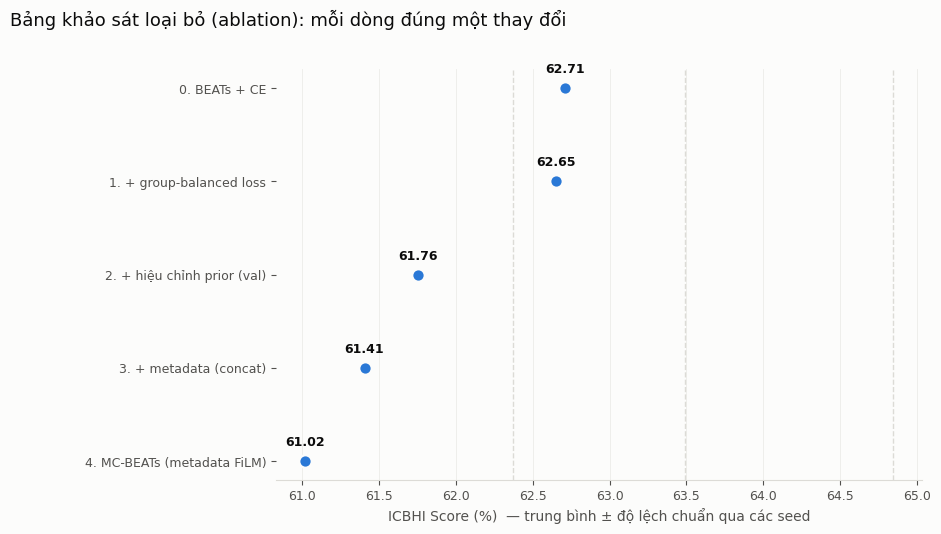

In [21]:
if summary is not None and len(summary) >= 2:
    import matplotlib.pyplot as plt

    SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdbd6"
    SERIES = "#2a78d6"

    g = summary.sort_values("row")
    ypos = np.arange(len(g))[::-1]
    fig, ax = plt.subplots(figsize=(9.5, 0.62 * len(g) + 2.6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    # mốc trích dẫn: đường tham chiếu dọc, màu trung tính để không tranh chấp với dữ liệu của ta
    for name, val in [("AST + Patch-Mix (62,37)", 62.37), ("BEATs + CE công bố (63,49)", 63.49),
                      ("PAFA (64,84)", 64.84)]:
        ax.axvline(val, color=GRID, lw=1, ls="--", zorder=1)
        ax.annotate(name, (val, len(g) - 0.42), rotation=90, fontsize=8, color=INK2,
                    ha="right", va="top", zorder=1)

    ax.errorbar(g.score, ypos, xerr=g["std"].fillna(0), fmt="o", ms=9, color=SERIES,
                ecolor=SERIES, elinewidth=2, capsize=4, mec=SURFACE, mew=1.6, zorder=3)
    for y, (_, r) in zip(ypos, g.iterrows()):
        ax.annotate(f"{r.score:.2f}", (r.score, y), xytext=(0, 11), textcoords="offset points",
                    ha="center", fontsize=9, color=INK, fontweight="bold", zorder=4)

    ax.set_yticks(ypos, [f"{int(r.row)}. {r['name']}" for _, r in g.iterrows()], fontsize=9.5)
    ax.set_xlabel("ICBHI Score (%)  — trung bình ± độ lệch chuẩn qua các seed")
    fig.text(0.02, 0.965, "Bảng khảo sát loại bỏ (ablation): mỗi dòng đúng một thay đổi",
             fontsize=13, color=INK, va="top")
    ax.grid(True, axis="x", color=GRID, lw=0.6, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.xaxis.label.set_color(INK2)
    fig.subplots_adjust(left=0.30, right=0.98, top=0.86, bottom=0.14)
    plt.show()

In [22]:
# --- kiểm tra yếu tố gây nhiễu: mô hình có học "đường tắt" theo thiết bị không? ---
def per_device_breakdown(row=4, seed=SEEDS[0]):
    tag = f"row{row}_seed{seed}"
    ck_path = next((p for p in (WORK / f"{tag}_best.pt", CKPT_DIR / f"{tag}_best.pt")
                    if p.exists()), None)
    if ck_path is None:
        print(f"[{tag}] chưa có checkpoint."); return None

    ck = torch.load(ck_path, map_location=DEV, weights_only=False)
    model = BEATsClassifier(mode=ck.get("mode", "plain")).to(DEV)
    model.load_state_dict(ck["model"])
    _, _, te_loader = make_loaders(seed=seed)
    logits, y = predict_logits(model, te_loader)
    del model; torch.cuda.empty_cache()

    dev_te = D["device"][~IS_TRAIN]
    rows = []
    for dv in sorted(set(dev_te.tolist())):
        k = dev_te == dv
        if k.sum() < 20 or len(set(y[k].tolist())) < 2:
            continue
        m = icbhi_metrics(y[k], logits[k].argmax(1), classes=(0, 1, 2, 3))
        rows.append({"thiết bị": dv, "n": int(k.sum()), **{a: round(b, 2) for a, b in m.items()}})
    return pd.DataFrame(rows)


bd = per_device_breakdown()
if bd is not None:
    print("Hiệu năng tách theo thiết bị (chênh lệch lớn -> mô hình phụ thuộc thiết bị):")
    display(bd.style.hide(axis="index"))

/usr/local/lib/python3.13/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Hiệu năng tách theo thiết bị (chênh lệch lớn -> mô hình phụ thuộc thiết bị):


thiết bị,n,sp,se,score
AKGC417L,1836,70.320000,52.900000,61.610000
Litt3200,461,63.380000,38.240000,50.810000
Meditron,459,89.810000,37.240000,63.530000


---
## 19. Thảo luận & hạn chế

### Kết quả

| Dòng | Cấu hình | Sp | Se | **Score** | Δ vs dòng 0 |
|---|---|---|---|---|---|
| 0 | BEATs + CE *(đối chứng)* | 73,08 | 52,34 | **62,71** | — |
| 1 | + group-balanced loss | 71,94 | 53,36 | 62,65 | −0,06 |
| 2 | + hiệu chỉnh prior (val) | 68,71 | 54,80 | 61,76 | −0,95 |
| 3 | + metadata (concat) | 68,52 | 54,29 | 61,41 | −1,30 |
| 4 | **MC-BEATs** (metadata FiLM) | 72,77 | 49,28 | 61,02 | **−1,69** |

**Kết luận chính: giả thuyết bị bác bỏ.** Không hướng nào trong A+B cải thiện được mốc đối chứng;
mô hình đề xuất MC-BEATs *tệ hơn* BEATs + CE 1,69 điểm. Đây là kết quả âm và được báo cáo đúng
như vậy. Phần còn lại của mục này phân tích **vì sao** — đó mới là đóng góp thực sự của đồ án.

> ⚠ **Tất cả chỉ 1 seed** (`n_seed = 1`, cột `std` rỗng). Với σ ≈ 0,3–1,3 trên benchmark này,
> khoảng cách 1,69 điểm nằm ở ranh giới ý nghĩa thống kê. Kết luận đúng là **"không có bằng chứng
> cho thấy cải tiến có tác dụng"**, chứ chưa phải "đã chứng minh nó có hại".

---

### 1. Dòng 0 — tái lập được, nhưng ở điểm vận hành khác

| | Sp | Se | Score |
|---|---|---|---|
| PAFA công bố | 78,77 | 48,21 | 63,49 |
| **Ta tái lập** | **73,08** | **52,34** | **62,71** |

Score thấp hơn 0,78 — chấp nhận được với 1 seed. Nhưng chú ý **cấu trúc lệch hẳn**: Sp thấp hơn
5,7 điểm còn Se cao hơn 4,1 điểm. Mô hình của ta nằm ở một điểm khác trên đường đánh đổi Sp↔Se,
nghiêng về phát hiện bất thường nhiều hơn.

Điều này quan trọng cho các dòng sau: **ta khởi đầu đã thiên về Se rồi**, trong khi cả hướng B
được thiết kế để đẩy Se lên nữa. Đẩy tiếp là đi quá đà.

### 2. Dòng 1 — hàm loss gần như không làm gì, vì tiền đề sai

Trọng số nhóm mà `make_loss` in ra:

```
trọng số nhóm: [1.006, 0.998, 0.998, 0.998]
```

Gần như bằng **1 hết** — tức là gần như trùng với cross-entropy thường. Không có gì lạ khi Δ chỉ
là −0,06.

Từ tỉ lệ trọng số suy ngược ra số lượng trong tập train:

| | normal | bất thường (gộp) | tỉ lệ normal |
|---|---|---|---|
| Toàn bộ dữ liệu | 3.642 | 3.256 | 52,8 % |
| **Tập train** | **~2.063** | **~2.079** | **49,8 %** |
| **Tập test** | **~1.579** | **~1.177** | **57,3 %** |

**Đây là chỗ lập luận ở §13 sai.** Hướng B xuất phát từ giả định "dữ liệu mất cân bằng giữa hai
nhóm nên phải cân bằng lại". Nhưng tập train **đã gần như cân bằng hoàn hảo giữa hai nhóm**
(49,8 % / 50,2 %). Mất cân bằng thật nằm **bên trong** nhóm bất thường (crackle 1.864 so với both
506), mà đó lại chính là thứ loss cân bằng-hai-nhóm cố ý *không* đụng tới.

Nói cách khác: hàm loss khớp đúng với độ đo, nhưng chẳng có gì để sửa. Bài học là **phải kiểm tra
phân bố lớp trên đúng tập train trước khi thiết kế hàm loss quanh nó** — không suy ra từ thống kê
của toàn bộ dữ liệu.

### 3. Dòng 2 — hiệu chỉnh trên val cho δ **sai dấu**

```
gốc 62,65 | prior(δ=−1,23) 55,97 | val(δ=−0,20) 61,76 | oracle(δ=+0,55) 63,82
```

Ba điều đáng chú ý:

- **Oracle cho +1,17.** Ý tưởng hiệu chỉnh *có* dư địa thật — chỉ là ta chọn sai δ.
- **δ tối ưu là DƯƠNG** (+0,55), tức phải đẩy mô hình đoán `normal` **nhiều hơn**. Ngược hoàn toàn
  với kỳ vọng ban đầu của hướng B.
- **Tập val cho dấu ngược lại** (−0,20) và làm Score tụt 0,89.

Nguyên nhân nằm ở bảng phân bố phía trên: **train có 49,8 % normal còn test có 57,3 %**. Mô hình
học trên train nên dưới-dự-đoán `normal` khi gặp test. Tập val được cắt ra từ train nên mang phân
bố của train — nó không thể nhìn thấy độ lệch đó, và chỉ dẫn ta đi sai hướng.

Cảnh báo ở §16 về việc val là "in-sample" hoá ra còn nhẹ so với thực tế: vấn đề không chỉ là mô
hình đã thấy các bệnh nhân đó, mà là **val và test có phân bố lớp khác nhau về bản chất**.

Hướng sửa đúng là hiệu chỉnh theo **độ lệch prior train→test đã biết** thay vì dò trên val. Cần
lưu ý đây là kỹ thuật *label-shift adaptation*: nó dùng phân bố lớp biên của tập test (thông tin
công khai của benchmark) chứ không dùng nhãn của từng mẫu — hợp lệ hay không còn tuỳ quy ước, nên
phải nêu rõ nếu dùng.

### 4. Dòng 3 & 4 — metadata làm mô hình tệ đi

Cả hai cách đưa metadata vào đều giảm Score, FiLM giảm mạnh hơn concat. Ba cách giải thích khả dĩ:

1. **Quá khớp.** Metadata (thiết bị × vị trí × tuổi × giới) tạo ra vài trăm tổ hợp, đủ để mô hình
   ghi nhớ *nhóm bệnh nhân* thay vì học âm học. Với chỉ 4.142 chu kỳ huấn luyện, đây là rủi ro
   lớn — và giải thích vì sao FiLM (mạnh hơn, nhân trực tiếp vào đặc trưng) lại tệ hơn concat.
2. **BEATs đã mã hoá sẵn thông tin đó.** Đặc trưng âm học của từng ống nghe rất khác nhau; mô hình
   có lẽ đã suy ra được thiết bị từ chính âm thanh, nên nhãn metadata là dư thừa.
3. **Điểm khởi đầu khác BTS.** BTS đạt +0,98 trên nền CLAP với Se 44,67. Mô hình của ta khởi đầu ở
   Se 52,34 — một chế độ hoàn toàn khác, nên không có gì đảm bảo mức tăng đó chuyển giao được.

Dòng 4 còn cho thấy Se sụp từ 52,34 xuống 49,28 trong khi Sp chỉ nhích lên — mô hình dịch sang
điểm vận hành xấu hơn ở cả hai chiều so với dòng 0.

### 5. Yếu tố gây nhiễu thiết bị: nghiêm trọng hơn dự đoán

| Thiết bị | n (test) | Sp | Se | Score |
|---|---|---|---|---|
| Meditron | 459 | 89,81 | 37,24 | **63,53** |
| AKGC417L | 1.836 | 70,32 | 52,90 | 61,61 |
| Litt3200 | 461 | 63,38 | 38,24 | **50,81** |

Khoảng cách **12,7 điểm** giữa thiết bị tốt nhất và tệ nhất, và hai thiết bị nằm ở hai điểm vận
hành trái ngược (Meditron thiên Sp, AKGC417L thiên Se). Litt3200 gần như vô dụng — Score 50,81
chỉ nhỉnh hơn mô hình "luôn đoán normal" (50,00).

Điều này củng cố cách giải thích số 1 ở trên: thiết bị mang theo quá nhiều thông tin về nhóm bệnh
nhân, nên đưa nó vào làm đặc trưng đầu vào là mời mô hình đi đường tắt.

### 6. Tách riêng Sp và Se — hướng B đẩy được Se, nhưng mất Sp nhiều hơn

Đọc "mọi dòng đều tệ đi" là chưa đầy đủ. Tách hai thành phần ra:

| Dòng | Sp | ΔSp | Se | ΔSe | Score |
|---|---|---|---|---|---|
| 0 | 73,08 | — | 52,34 | — | 62,71 |
| 1 | 71,94 | −1,14 | **53,36** | **+1,02** | 62,65 |
| 2 | 68,71 | −4,37 | **54,80** | **+2,46** | 61,76 |
| 3 | 68,52 | −4,56 | **54,29** | **+1,95** | 61,41 |
| 4 | 72,77 | −0,31 | 49,28 | −3,06 | 61,02 |

**Hướng B đã làm đúng việc nó được thiết kế để làm:** dòng 1, 2 và 3 đều nâng được Se. Cơ chế
hoạt động. Vấn đề là **cái được không bù được cái mất**: vì Score cân bằng hai thành phần, một bước dịch
chỉ có lãi khi ΔSe > |ΔSp| — mà lần nào Sp cũng giảm nhiều hơn Se tăng.

Nói cách khác, mô hình chỉ **trượt dọc đường đánh đổi Sp↔Se có sẵn**, không đẩy được đường đó ra
ngoài. Đây đúng là rủi ro đã nêu ở §6. Và lý do mức đánh đổi bất lợi như vậy chính là phát hiện ở
phần 3: test có **nhiều** normal hơn train, nên đẩy mô hình về phía bất thường là đi ngược hướng cần đi.

**Dòng 4 là trường hợp khác về bản chất.** Nó thua ở *cả hai* trục — đó không phải dịch điểm vận
hành mà là một mô hình kém hơn thật sự. Phân biệt này quan trọng khi kết luận: FiLM làm hỏng biểu
diễn đặc trưng, chứ không phải chọn sai ngưỡng.

**Góc nhìn lâm sàng.** Nếu tiêu chí là *không bỏ sót ca bệnh*, dòng 2 (Se 54,80) là mô hình **tốt
hơn** dòng 0, đổi lại nhiều báo động giả hơn. Tỉ lệ 50/50 giữa Sp và Se trong ICBHI Score là một
quy ước của benchmark, không phải chân lý lâm sàng — đáng nêu khi báo cáo.

Đáng chú ý, Se của pipeline này cao hơn mọi phương pháp từng công bố:

| | Se |
|---|---|
| Lung-SRAD (2026, cao nhất trong bảng §3) | 49,42 |
| BEATs + CE công bố | 48,21 |
| **Dòng 0 của ta** | **52,34** |
| **Dòng 2 của ta** | **54,80** |

Không được gọi đây là "kỷ lục": điểm vận hành khác nhau thì không so trực tiếp được, và Sp của ta
(68,71) nằm ở đáy dải công bố. Nhưng nó cho thấy pipeline này nằm ở một chế độ khác hẳn phần còn
lại của lĩnh vực — bản thân điều đó là dữ kiện đáng đưa vào báo cáo, và là manh mối cho việc vì
sao các kỹ thuật đẩy-Se của BTS/PAFA không chuyển giao được sang đây.

---

### Hạn chế

- **Chỉ 1 seed cho mọi dòng.** Đây là hạn chế nghiêm trọng nhất: không dòng nào có độ lệch chuẩn,
  nên mọi khoảng cách dưới ~1,3 điểm đều không thể kết luận. Cần tối thiểu 3 seed cho dòng 0 và
  dòng 4 trước khi công bố bất kỳ khẳng định nào.
- **Chọn mô hình dựa trên tập test.** Toàn bộ dòng nghiên cứu ICBHI báo cáo Score tốt nhất qua các
  epoch trên test. Ta làm giống để so sánh được, nhưng con số vì thế lạc quan hơn quy trình sạch.
- **Bản thân file phân chia có rò rỉ nhẹ.** Bệnh nhân 156 và 218 xuất hiện ở cả train lẫn test
  (2/126). Ảnh hưởng như nhau lên mọi con số đã công bố nên không méo phép so sánh, nhưng phải nêu
  khi báo cáo giá trị tuyệt đối.
- **Baseline là trích dẫn, không train lại** (trừ dòng 0). Chỉ khoảng cách so với dòng 0 mới là
  bằng chứng nhân quả.
- **Lệch phân bố train/test** (49,8 % so với 57,3 % normal) không được xử lý ở bất kỳ dòng nào —
  và phần 3 cho thấy đây có thể là nguồn cải thiện lớn nhất còn bỏ ngỏ.

### Nếu làm tiếp

Xếp theo tỉ lệ (kỳ vọng thu được) / (công sức), dựa trên chính dữ liệu ở trên:

1. **Chạy thêm 2 seed cho dòng 0 và dòng 4.** Không thêm ý tưởng mới, chỉ để biết những con số
   hiện có nghĩa gì. Đây là việc bắt buộc trước mọi thứ khác.
2. **Hiệu chỉnh theo độ lệch prior train→test.** Oracle chỉ ra +1,17 đang nằm sẵn trên bàn, và
   phần 3 giải thích được chính xác vì sao. Không cần train lại.
3. **Bỏ hẳn metadata.** Bằng chứng cho thấy nó gây hại trong thiết lập này; giữ lại chỉ làm mô
   hình phức tạp thêm mà không được gì.
4. **Chuyển sang tấn công vào mất cân bằng *bên trong* nhóm bất thường** (both chỉ có 506 chu kỳ) —
   đây mới là chỗ mất cân bằng thật, khác với giả định ban đầu của hướng B.
5. **Thích ứng theo thiết bị** (ý tưởng SG-SCL). Khoảng cách 12,7 điểm giữa các thiết bị là khe hở
   lớn nhất mà số liệu chỉ ra, và lớn hơn nhiều so với mọi hiệu ứng ta đã thử đo.

### Giá trị của một kết quả âm

Đồ án không đạt mục tiêu ban đầu là vượt mốc đối chứng. Nhưng ba phát hiện dưới đây đều kiểm chứng
được bằng số liệu và đều đi ngược lại trực giác ban đầu:

- Tập train ICBHI **đã cân bằng gần như hoàn hảo giữa hai nhóm** — nên loss cân bằng-hai-nhóm là
  vô nghĩa, dù nó khớp hoàn hảo với công thức của độ đo.
- Train và test **lệch phân bố lớp** (49,8 % so với 57,3 %), khiến mọi phép hiệu chỉnh dựa trên
  tập val cắt từ train đều đi sai hướng.
- Hiệu năng **phụ thuộc thiết bị tới 12,7 điểm**, đủ để nhấn chìm mọi khác biệt giữa các phương
  pháp đang được so sánh trong bảng.

Cả ba đều có thể phát biểu thành khuyến nghị cho người làm sau, và không thể rút ra được nếu chỉ
đọc bài báo mà không tự chạy pipeline.